<a href="https://colab.research.google.com/github/sv9-ru/flow_meter/blob/main/%D0%9E%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D1%8F_%D0%BD%D0%B0_%D0%BD%D0%B0%D1%88%D0%B8%D1%85_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Введение

[Исходный сайт](https://cmfdata.susu.ru/)  

Набор 1 (103 точки): Полный эталонный набор данных.  
Набор 2 (53 точки): Сохранены все линии расхода, но исключена каждая вторая точка GVF.  
Набор 3 (51 точка): Сохранены все точки GVF, но исключена каждая вторая линия расхода.  
Набор 4 (27 точек): Самый разреженный набор; исключена каждая вторая линия расхода и каждая вторая точка GVF.  

## Библиотеки проекта

In [1]:
!pip install mlflow -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.7 MB/s eta 0:00:00


In [2]:
# ============================================================================
# DATA MANIPULATION AND NUMERICAL OPERATIONS
# ============================================================================
import numpy as np
import pandas as pd

# ============================================================================
# MACHINE LEARNING MODELS AND PREPROCESSING
# ============================================================================
from sklearn import svm, metrics, preprocessing
from sklearn.utils import shuffle
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ============================================================================
# DEEP LEARNING (TENSORFLOW/KERAS)
# ============================================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, layers, callbacks
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers

# ============================================================================
# VISUALIZATION
# ============================================================================
import matplotlib.pyplot as plt

# ============================================================================
# FILE I/O AND PERSISTENCE
# ============================================================================
import pickle
import joblib
import json
import os
from pathlib import Path

# ============================================================================
# DATA DOWNLOAD AND EXTERNAL TOOLS
# ============================================================================
import gdown

# ============================================================================
# SCIENTIFIC COMPUTING
# ============================================================================
from scipy.spatial import KDTree

# ============================================================================
# UTILITIES AND MISC
# ============================================================================
import time
from datetime import datetime as dt
from typing import Dict, Optional

# ============================================================================
# NOTEBOOK DISPLAY
# ============================================================================
from IPython.display import display

In [3]:
# ID таблицы
file_id = "1SxXjje079Bq4uCQSOH7zAEowBxuYgx9r"

# Ссылка для gdown
url = f"https://drive.google.com/uc?id={file_id}"

# Скачиваем файл и сохраняем его под именем "my_file.xlsx"
output = "my_file.xlsx"
gdown.download(url, output, quiet=False)


# Теперь файл "my_file.xlsx" есть в среде Colab, и его можно прочитать
df = pd.read_excel(output)

Downloading...
From: https://drive.google.com/uc?id=1SxXjje079Bq4uCQSOH7zAEowBxuYgx9r
To: /content/my_file.xlsx
100%|██████████| 251k/251k [00:00<00:00, 63.5MB/s]


## подготовка данных

In [4]:
df = pd.read_excel('/content/my_file.xlsx', sheet_name='Сводная таблица')

In [5]:
df

,Unnamed: 0,Опытный расходомер,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Эталонный расходомер,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,NaN,MassFlow,Density,Temperature,Delay,Frequency,gvf,MassFlow,Density,Temperature,Delay,Frequency
1,Начало блока 1,367.426044,997.231933,19.002244,-5.114089,89.993555,0,369.078089,1002.589,0,-4.829933,94.077026
2,NaN,353.762378,890.067267,19.012644,-4.9184,90.634878,24.451525,347.851044,1002.64,0,-4.552822,94.076714
3,NaN,344.735089,803.081022,19.017978,-4.788067,91.174095,27.897892,340.611689,1002.661733,0,-4.458356,94.076576
4,NaN,334.052556,748.701644,19.028756,-4.637089,91.514323,30.803455,333.9184,1002.688667,0,-4.371022,94.076407
5,NaN,302.198622,673.142311,19.030022,-4.178089,91.970039,34.95707,327.441022,1002.710289,0,-4.286467,94.076274
6,NaN,295.480778,622.675778,19.0404,-4.082267,92.31625,38.937307,323.009756,1002.734244,0,-4.228644,94.076127
7,NaN,293.952156,557.586644,19.049733,-4.059711,92.736252,45.181359,316.455867,1002.766378,0,-4.143067,94.075932
8,Конец блока 1,268.628556,496.413778,19.061467,-3.695844,93.131992,51.012766,308.848533,1002.790622,0,-4.0438,94.075781
9,Начало блока 2,744.248378,997.324333,19.083444,-10.520644,89.991505,0,746.172733,1002.903267,0,-9.751533,94.075084


In [6]:
MFRref   = 7 #
rho_liquid    = 8 # Pliquid

MFRobs   = 1
rho_obs    = 2 #Pobs
# ddtrue ~ GVf 6
DDtrue = 6
row_start = 1

In [7]:
df.loc[1:, 'MFRerr'] = ((df.loc[1:, df.columns[MFRobs]] - df.loc[1:, df.columns[MFRref]]) / df.loc[1:, df.columns[MFRref]]) * 100
df.loc[1:, 'DDerr'] = abs((((df.iloc[1:, rho_liquid] - df.iloc[1:, rho_obs])/(df.iloc[1:, rho_liquid])) * 100)) - df.iloc[1:, DDtrue]

In [8]:
df

,Unnamed: 0,Опытный расходомер,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Эталонный расходомер,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,MFRerr,DDerr
0,NaN,MassFlow,Density,Temperature,Delay,Frequency,gvf,MassFlow,Density,Temperature,Delay,Frequency,NaN,NaN
1,Начало блока 1,367.426044,997.231933,19.002244,-5.114089,89.993555,0,369.078089,1002.589,0,-4.829933,94.077026,-0.447614,0.534323
2,NaN,353.762378,890.067267,19.012644,-4.9184,90.634878,24.451525,347.851044,1002.64,0,-4.552822,94.076714,1.699386,-13.223893
3,NaN,344.735089,803.081022,19.017978,-4.788067,91.174095,27.897892,340.611689,1002.661733,0,-4.458356,94.076576,1.210587,-7.992803
4,NaN,334.052556,748.701644,19.028756,-4.637089,91.514323,30.803455,333.9184,1002.688667,0,-4.371022,94.076407,0.040176,-5.472858
5,NaN,302.198622,673.142311,19.030022,-4.178089,91.970039,34.95707,327.441022,1002.710289,0,-4.286467,94.076274,-7.708991,-2.089353
6,NaN,295.480778,622.675778,19.0404,-4.082267,92.31625,38.937307,323.009756,1002.734244,0,-4.228644,94.076127,-8.522646,-1.035094
7,NaN,293.952156,557.586644,19.049733,-4.059711,92.736252,45.181359,316.455867,1002.766378,0,-4.143067,94.075932,-7.111169,-0.7862
8,Конец блока 1,268.628556,496.413778,19.061467,-3.695844,93.131992,51.012766,308.848533,1002.790622,0,-4.0438,94.075781,-13.022557,-0.515999
9,Начало блока 2,744.248378,997.324333,19.083444,-10.520644,89.991505,0,746.172733,1002.903267,0,-9.751533,94.075084,-0.257897,0.556278


In [9]:
MFR = MFRobs
DD = rho_obs

MFR_err = 12
DD_err = 13

row_start = 1

In [10]:
mfr_idx = 1   # индекс столбца с MFR
gvf_idx = 2   # индекс столбца с GVF

unique_mfr = sorted(df.iloc[1:, mfr_idx].unique())
unique_gvf = sorted(df.iloc[1:, gvf_idx].unique())

gvf_subset = unique_gvf[::2]
dataset2 = df[df.iloc[:, gvf_idx].isin(gvf_subset)]
dataset2_excluded = df[~df.iloc[:, gvf_idx].isin(gvf_subset)]

mfr_subset = unique_mfr[::2]
dataset3 = df[df.iloc[:, mfr_idx].isin(mfr_subset)]
dataset3_excluded = df[~df.iloc[:, mfr_idx].isin(mfr_subset)]

dataset4 = df[df.iloc[:, mfr_idx].isin(mfr_subset) & df.iloc[:, gvf_idx].isin(gvf_subset)]
dataset4_excluded = df[~(df.iloc[:, mfr_idx].isin(mfr_subset) & df.iloc[:, gvf_idx].isin(gvf_subset))]

#================================
mask = (df.index + 1) % 8 == 0   # каждая третья, начиная с третьей строки

# Создаём первую таблицу: заголовки и выбранные строки
df_selected = df[mask].copy()

# Создаём вторую таблицу: все остальные строки
df_remaining = df[~mask].copy()


In [11]:
df_remaining.shape

(36, 14)

In [12]:
df_selected.shape

(5, 14)

In [13]:
# Сохраняем первую строку df как отдельный DataFrame
first_row = df.iloc[[0]]  # двойные скобки, чтобы сохранить структуру DataFrame
df_selected = pd.concat([first_row, df_selected])

In [14]:
# Extracting research data
# Полный датасет
X_test_full = df.iloc[row_start:, [MFR, DD]].values.astype(float)
y_test_full_MFR = df.iloc[row_start:, [MFR_err]].values.astype(float)
y_test_full_DD = df.iloc[row_start:, [DD_err]].values.astype(float)

# Полная обучающая выборка
X_train_full = df.iloc[row_start:, [MFR, DD]].values.astype(float)
y_train_full_MFR = df.iloc[row_start:, [MFR_err]].values.astype(float)
y_train_full_DD = df.iloc[row_start:, [DD_err]].values.astype(float)

# Shuffle train data
X_train_full, y_train_full_MFR, y_train_full_DD = shuffle(
    X_train_full,
    y_train_full_MFR,
    y_train_full_DD,
    random_state=42
)

# === НОРМАЛИЗАЦИЯ ДЛЯ ПОЛНЫХ ДАННЫХ ===
# Создаем scaler'ы для X и y на полных обучающих данных
scaler_X_full = preprocessing.StandardScaler().fit(X_train_full)
scaler_y_MFR_full = preprocessing.StandardScaler().fit(y_train_full_MFR)
scaler_y_DD_full = preprocessing.StandardScaler().fit(y_train_full_DD)

# Масштабируем полные данные
X_train_full_scaled = scaler_X_full.transform(X_train_full)
y_train_full_MFR_scaled = scaler_y_MFR_full.transform(y_train_full_MFR).ravel()
y_train_full_DD_scaled = scaler_y_DD_full.transform(y_train_full_DD).ravel()

X_test_full_scaled = scaler_X_full.transform(X_test_full)
y_test_full_MFR_scaled = scaler_y_MFR_full.transform(y_test_full_MFR).ravel()
y_test_full_DD_scaled = scaler_y_DD_full.transform(y_test_full_DD).ravel()

In [15]:
# ----------------------------------------------------------------------
# dataset2
X_test_full_ds2 = dataset2.iloc[row_start:, [MFR, DD]].values.astype(float)
y_test_full_MFR_ds2 = dataset2.iloc[row_start:, [MFR_err]].values.astype(float)
y_test_full_DD_ds2 = dataset2.iloc[row_start:, [DD_err]].values.astype(float)

X_train_full_ds2 = dataset2.iloc[row_start:, [MFR, DD]].values.astype(float)
y_train_full_MFR_ds2 = dataset2.iloc[row_start:, [MFR_err]].values.astype(float)
y_train_full_DD_ds2 = dataset2.iloc[row_start:, [DD_err]].values.astype(float)

# Shuffle train data
X_train_full_ds2, y_train_full_MFR_ds2, y_train_full_DD_ds2 = shuffle(
    X_train_full_ds2,
    y_train_full_MFR_ds2,
    y_train_full_DD_ds2,
    random_state=42
)

# Нормализация
scaler_X_ds2 = preprocessing.StandardScaler().fit(X_train_full_ds2)
scaler_y_MFR_ds2 = preprocessing.StandardScaler().fit(y_train_full_MFR_ds2)
scaler_y_DD_ds2 = preprocessing.StandardScaler().fit(y_train_full_DD_ds2)

X_train_full_ds2_scaled = scaler_X_ds2.transform(X_train_full_ds2)
y_train_full_MFR_ds2_scaled = scaler_y_MFR_ds2.transform(y_train_full_MFR_ds2).ravel()
y_train_full_DD_ds2_scaled = scaler_y_DD_ds2.transform(y_train_full_DD_ds2).ravel()

X_test_full_ds2_scaled = scaler_X_ds2.transform(X_test_full_ds2)
y_test_full_MFR_ds2_scaled = scaler_y_MFR_ds2.transform(y_test_full_MFR_ds2).ravel()
y_test_full_DD_ds2_scaled = scaler_y_DD_ds2.transform(y_test_full_DD_ds2).ravel()

# ----------------------------------------------------------------------
# dataset3
X_test_full_ds3 = dataset3.iloc[row_start:, [MFR, DD]].values.astype(float)
y_test_full_MFR_ds3 = dataset3.iloc[row_start:, [MFR_err]].values.astype(float)
y_test_full_DD_ds3 = dataset3.iloc[row_start:, [DD_err]].values.astype(float)

X_train_full_ds3 = dataset3.iloc[row_start:, [MFR, DD]].values.astype(float)
y_train_full_MFR_ds3 = dataset3.iloc[row_start:, [MFR_err]].values.astype(float)
y_train_full_DD_ds3 = dataset3.iloc[row_start:, [DD_err]].values.astype(float)

X_train_full_ds3, y_train_full_MFR_ds3, y_train_full_DD_ds3 = shuffle(
    X_train_full_ds3,
    y_train_full_MFR_ds3,
    y_train_full_DD_ds3,
    random_state=42
)

scaler_X_ds3 = preprocessing.StandardScaler().fit(X_train_full_ds3)
scaler_y_MFR_ds3 = preprocessing.StandardScaler().fit(y_train_full_MFR_ds3)
scaler_y_DD_ds3 = preprocessing.StandardScaler().fit(y_train_full_DD_ds3)

X_train_full_ds3_scaled = scaler_X_ds3.transform(X_train_full_ds3)
y_train_full_MFR_ds3_scaled = scaler_y_MFR_ds3.transform(y_train_full_MFR_ds3).ravel()
y_train_full_DD_ds3_scaled = scaler_y_DD_ds3.transform(y_train_full_DD_ds3).ravel()

X_test_full_ds3_scaled = scaler_X_ds3.transform(X_test_full_ds3)
y_test_full_MFR_ds3_scaled = scaler_y_MFR_ds3.transform(y_test_full_MFR_ds3).ravel()
y_test_full_DD_ds3_scaled = scaler_y_DD_ds3.transform(y_test_full_DD_ds3).ravel()

# ----------------------------------------------------------------------
# dataset4
X_test_full_ds4 = dataset4.iloc[row_start:, [MFR, DD]].values.astype(float)
y_test_full_MFR_ds4 = dataset4.iloc[row_start:, [MFR_err]].values.astype(float)
y_test_full_DD_ds4 = dataset4.iloc[row_start:, [DD_err]].values.astype(float)

X_train_full_ds4 = dataset4.iloc[row_start:, [MFR, DD]].values.astype(float)
y_train_full_MFR_ds4 = dataset4.iloc[row_start:, [MFR_err]].values.astype(float)
y_train_full_DD_ds4 = dataset4.iloc[row_start:, [DD_err]].values.astype(float)

X_train_full_ds4, y_train_full_MFR_ds4, y_train_full_DD_ds4 = shuffle(
    X_train_full_ds4,
    y_train_full_MFR_ds4,
    y_train_full_DD_ds4,
    random_state=42
)

scaler_X_ds4 = preprocessing.StandardScaler().fit(X_train_full_ds4)
scaler_y_MFR_ds4 = preprocessing.StandardScaler().fit(y_train_full_MFR_ds4)
scaler_y_DD_ds4 = preprocessing.StandardScaler().fit(y_train_full_DD_ds4)

X_train_full_ds4_scaled = scaler_X_ds4.transform(X_train_full_ds4)
y_train_full_MFR_ds4_scaled = scaler_y_MFR_ds4.transform(y_train_full_MFR_ds4).ravel()
y_train_full_DD_ds4_scaled = scaler_y_DD_ds4.transform(y_train_full_DD_ds4).ravel()

X_test_full_ds4_scaled = scaler_X_ds4.transform(X_test_full_ds4)
y_test_full_MFR_ds4_scaled = scaler_y_MFR_ds4.transform(y_test_full_MFR_ds4).ravel()
y_test_full_DD_ds4_scaled = scaler_y_DD_ds4.transform(y_test_full_DD_ds4).ravel()

# ----------------------------------------------------------------------
# df_remaining
X_test_full_rem = df_remaining.iloc[row_start:, [MFR, DD]].values.astype(float)
y_test_full_MFR_rem = df_remaining.iloc[row_start:, [MFR_err]].values.astype(float)
y_test_full_DD_rem = df_remaining.iloc[row_start:, [DD_err]].values.astype(float)

X_train_full_rem = df_remaining.iloc[row_start:, [MFR, DD]].values.astype(float)
y_train_full_MFR_rem = df_remaining.iloc[row_start:, [MFR_err]].values.astype(float)
y_train_full_DD_rem = df_remaining.iloc[row_start:, [DD_err]].values.astype(float)

X_train_full_rem, y_train_full_MFR_rem, y_train_full_DD_rem = shuffle(
    X_train_full_rem,
    y_train_full_MFR_rem,
    y_train_full_DD_rem,
    random_state=42
)

scaler_X_rem = preprocessing.StandardScaler().fit(X_train_full_rem)
scaler_y_MFR_rem = preprocessing.StandardScaler().fit(y_train_full_MFR_rem)
scaler_y_DD_rem = preprocessing.StandardScaler().fit(y_train_full_DD_rem)

X_train_full_rem_scaled = scaler_X_rem.transform(X_train_full_rem)
y_train_full_MFR_rem_scaled = scaler_y_MFR_rem.transform(y_train_full_MFR_rem).ravel()
y_train_full_DD_rem_scaled = scaler_y_DD_rem.transform(y_train_full_DD_rem).ravel()

X_test_full_rem_scaled = scaler_X_rem.transform(X_test_full_rem)
y_test_full_MFR_rem_scaled = scaler_y_MFR_rem.transform(y_test_full_MFR_rem).ravel()
y_test_full_DD_rem_scaled = scaler_y_DD_rem.transform(y_test_full_DD_rem).ravel()

In [16]:
# ================== ПОДГОТОВКА ДАННЫХ ДЛЯ ИСКЛЮЧЕННЫХ ДАТАСЕТОВ ==================

# ----------------------------------------------------------------------
# dataset2_excluded
X_test_full_ds2_excluded = dataset2_excluded.iloc[row_start:, [MFR, DD]].values.astype(float)
X_train_full_ds2_excluded = dataset2_excluded.iloc[row_start:, [MFR, DD]].values.astype(float)

# Нормализация
scaler_X_ds2_excluded = preprocessing.StandardScaler().fit(X_train_full_ds2_excluded)
X_train_full_ds2_excluded_scaled = scaler_X_ds2_excluded.transform(X_train_full_ds2_excluded)

X_test_full_ds2_excluded_scaled = scaler_X_ds2_excluded.transform(X_test_full_ds2_excluded)


# ----------------------------------------------------------------------
# dataset3_excluded
X_test_full_ds3_excluded = dataset3_excluded.iloc[row_start:, [MFR, DD]].values.astype(float)
X_train_full_ds3_excluded = dataset3_excluded.iloc[row_start:, [MFR, DD]].values.astype(float)

# Нормализация
scaler_X_ds3_excluded = preprocessing.StandardScaler().fit(X_train_full_ds3_excluded)
X_train_full_ds3_excluded_scaled = scaler_X_ds3_excluded.transform(X_train_full_ds3_excluded)

X_test_full_ds3_excluded_scaled = scaler_X_ds3_excluded.transform(X_test_full_ds3_excluded)

# ----------------------------------------------------------------------
# dataset4_excluded
X_test_full_ds4_excluded = dataset4_excluded.iloc[row_start:, [MFR, DD]].values.astype(float)
X_train_full_ds4_excluded = dataset4_excluded.iloc[row_start:, [MFR, DD]].values.astype(float)

# Нормализация
scaler_X_ds4_excluded = preprocessing.StandardScaler().fit(X_train_full_ds4_excluded)
X_train_full_ds4_excluded_scaled = scaler_X_ds4_excluded.transform(X_train_full_ds4_excluded)

X_test_full_ds4_excluded_scaled = scaler_X_ds4_excluded.transform(X_test_full_ds4_excluded)

# ----------------------------------------------------------------------
# df_selected
X_test_full_selected = df_selected.iloc[row_start:, [MFR, DD]].values.astype(float)
X_train_full_selected = df_selected.iloc[row_start:, [MFR, DD]].values.astype(float)

# Нормализация
scaler_X_selected = preprocessing.StandardScaler().fit(X_train_full_selected)
X_train_full_selected_scaled = scaler_X_selected.transform(X_train_full_selected)

X_test_full_selected_scaled = scaler_X_selected.transform(X_test_full_selected)

In [17]:
# Список датасетов с их суффиксами и соответствующими переменными
datasets = [
    ('full', X_train_full_scaled, y_train_full_MFR_scaled, y_train_full_DD_scaled,
            X_test_full_scaled, y_test_full_MFR_scaled, y_test_full_DD_scaled),

    ('ds2', X_train_full_ds2_scaled, y_train_full_MFR_ds2_scaled, y_train_full_DD_ds2_scaled,
            X_test_full_ds2_scaled, y_test_full_MFR_ds2_scaled, y_test_full_DD_ds2_scaled),

    ('ds3', X_train_full_ds3_scaled, y_train_full_MFR_ds3_scaled, y_train_full_DD_ds3_scaled,
            X_test_full_ds3_scaled, y_test_full_MFR_ds3_scaled, y_test_full_DD_ds3_scaled),

    ('ds4', X_train_full_ds4_scaled, y_train_full_MFR_ds4_scaled, y_train_full_DD_ds4_scaled,
            X_test_full_ds4_scaled, y_test_full_MFR_ds4_scaled, y_test_full_DD_ds4_scaled),

    ('remaining', X_train_full_rem_scaled, y_train_full_MFR_rem_scaled, y_train_full_DD_rem_scaled,
            X_test_full_rem_scaled, y_test_full_MFR_rem_scaled, y_test_full_DD_rem_scaled),
]

## Вспомогательные функции

In [18]:
# ────────────────────────────────────────────────
# 1. Глобальный словарь (или можно передать свой)
experiments = {}

# Рассчет метрик
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    # Защита для MAPE от деления на 0
    y_true_stable = np.where(y_true == 0, 1e-9, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / y_true_stable)) * 100
    return {"MAE": mae, "RMSE": rmse, "MSE": mse, "MAPE": mape}

# Анализ чувствительности (реакция на шум 1%)
def check_sensitivity(model, X_test, y_pred_original):
    noise = np.random.normal(0, 0.01, X_test.shape)
    X_test_noisy = X_test + noise
    y_pred_noisy = model.predict(X_test_noisy)
    return np.mean(np.abs(y_pred_original - y_pred_noisy))

def save_experiment_results(
    model_name, training_type, target_name,
    y_true, y_pred,
    y_true_train=None, y_pred_train=None,
    execution_time=None, best_params=None,
    cv_std=None, sensitivity=None
):
    metrics = calculate_metrics(y_true, y_pred)

    # 1. Overfit Ratio с защитой от деления на ноль
    if y_true_train is not None and y_pred_train is not None:
        train_mae = calculate_metrics(y_true_train, y_pred_train)['MAE']
        if train_mae < 1e-7:
            metrics['Overfit_Ratio'] = 999.0
        else:
            metrics['Overfit_Ratio'] = round(metrics['MAE'] / train_mae, 3)

    # 2. Дополнительные метрики
    metrics['CV_Stability'] = round(abs(cv_std), 5) if cv_std is not None else None
    metrics['Sensitivity'] = round(sensitivity, 5) if sensitivity is not None else None
    metrics['Time'] = execution_time
    metrics['Params'] = best_params

    # 3. Запись в глобальный словарь experiments с динамическим созданием структуры
    if model_name not in experiments:
        experiments[model_name] = {}
    if training_type not in experiments[model_name]:
        experiments[model_name][training_type] = {}
    experiments[model_name][training_type][target_name] = metrics

In [19]:
# @title
def highlight_results(df, target=None, data_type=None, model_family=None):

    """
    df: исходный DataFrame
    target: 'MFR' или 'DD'
    data_type: 'full' или 'partial'
    model_family: подстрока (напр. 'KNN', 'KD-Tree', 'Weighted')
    """
    subset = df.copy()

    # Последовательная фильтрация
    if target:
        subset = subset[subset['Target'] == target]
    if data_type:
        subset = subset[subset['Data'] == data_type]
    if model_family:
        subset = subset[subset['Model'].str.contains(model_family, case=False)]

    if subset.empty:
        print("Данные по указанным фильтрам не найдены.")
        return None

    # Сортировка по возрастанию ошибки (лучшие сверху)
    subset = subset.sort_values(by='RMSE')

    # Настройка колонок для градиента (чем меньше, тем лучше -> зеленый)
    metrics_cols = ['MSE', 'RMSE', 'MAE', 'MAPE']

    # Формируем красивый заголовок
    title = f"Анализ моделей: Target={target or 'All'}, Data={data_type or 'All'}, Family={model_family or 'All'}"

    return subset.style.background_gradient(
        cmap='RdYlGn_r',  # Red-Yellow-Green reversed
        subset=metrics_cols
    ).format({
        'MAPE': '{:.2f}%',
        'MSE': '{:.4f}',
        'RMSE': '{:.4f}',
        'MAE': '{:.4f}'
    }).set_caption(title).set_table_styles([
        {'selector': 'caption', 'props': [('color', '#f8f9fa'), ('font-size', '16px'),
                                         ('background-color', '#343a40'), ('padding', '10px')]}
    ]).hide(axis='index') # Скрываем индекс для чистоты


In [20]:
# @title
def create_results_dataframe(experiments):
    rows = []
    for model_name, data_types in experiments.items():
        if not isinstance(data_types, dict): continue
        for t_type, targets in data_types.items():
            for t_name, metrics in targets.items():
                if metrics:
                    rows.append({
                        "Model": model_name,
                        "Data": t_type,
                        "Target": t_name,
                        "MAE": metrics.get("MAE"),
                        "Overfit_Ratio": metrics.get("Overfit_Ratio"),
                        "CV_Stability": metrics.get("CV_Stability"),
                        "Sensitivity": metrics.get("Sensitivity"),
                        "Time (sec)": metrics.get("Time"),
                        "Best Params": str(metrics.get("Params"))
                    })
    return pd.DataFrame(rows)


In [21]:
# @title
def highlight_results(df, target='MFR'):
    subset = df[df['Target'] == target]
    return subset.style.background_gradient(subset=['MAE'], cmap='RdYlGn_r') \
                       .background_gradient(subset=['Overfit_Ratio'], cmap='YlOrRd') # Красный — много переобучения

In [22]:
# === СОХРАНЕНИЕ МОДЕЛЕЙ ===
from tensorflow.keras.models import save_model
os.makedirs('/content/saved_models', exist_ok=True)

def save_trained_model(model, model_name, training_type, target_name):
    base_path = f'/content/saved_models/{model_name}_{training_type}_{target_name}'

    if isinstance(model, (keras.models.Model, keras.Sequential)):  # NeuralNetwork
        save_model(model, base_path + '.keras')
        print(f"✅ NeuralNetwork сохранена: {base_path}.keras")
    else:
        with open(base_path + '.pkl', 'wb') as f:
            pickle.dump(model, f)
        print(f"✅ Модель сохранена: {base_path}.pkl")

# KNN

## Функции

In [23]:

# Функции весов
def gaussian_weights(distances, sigma=1.0):
    return np.exp(-(distances ** 2) / (2 * sigma ** 2))

def triangular_weights(distances):
    return np.maximum(0, 1 - distances / np.max(distances))

def rectangular_weights(distances):
    return np.ones_like(distances)

# Класс для гауссовых весов (поддерживает pickle)
class GaussianWeights:
    def __init__(self, sigma):
        self.sigma = sigma
    def __call__(self, distances):
        return gaussian_weights(distances, self.sigma)

# Функция build_knn (с использованием класса)
def build_knn(model_type, sigma=None, **params):
    params.pop("sigma", None)
    if model_type == "knn":
        return KNeighborsRegressor(weights='uniform', algorithm='auto', **params)
    if model_type == "weighted":
        return KNeighborsRegressor(weights='distance', algorithm='auto', **params)
    if model_type == "weighted_gaussian":
        return KNeighborsRegressor(weights=GaussianWeights(sigma), algorithm='auto', **params)
    if model_type == "kd":
        return KNeighborsRegressor(weights='uniform', algorithm='kd_tree', **params)
    if model_type == "kd_rectangular":
        return KNeighborsRegressor(weights=rectangular_weights, algorithm='kd_tree', **params)
    if model_type == "kd_triangular":
        return KNeighborsRegressor(weights=triangular_weights, algorithm='kd_tree', **params)
    if model_type == "kd_gaussian":
        return KNeighborsRegressor(weights=GaussianWeights(sigma), algorithm='kd_tree', **params)
    raise ValueError(f"Unknown model type: {model_type}")


knn_param_grid = {
   # 'n_neighbors': [3, 5, 10, 15],
    #'leaf_size': [30],
    #'p': [2]
    'n_neighbors': [3, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51, 71, 101],
    'leaf_size': [10, 20, 30, 40, 50, 60, 80, 100],
    'p': [1, 2, 3],
}

gaussian_sigmas = [0.3, 0.5, 1.0, 2.0]

def train_and_log_knn(model_key, model_type, X_train, y_train, X_test, y_test, training_type, target_name):
    start_time = time.time()
    best_model, best_score, final_params, cv_std = None, np.inf, {}, 0

    sigmas = gaussian_sigmas if 'gaussian' in model_type else [None]
    for sigma in sigmas:
        model = build_knn(model_type, sigma=sigma)
        grid = GridSearchCV(model, knn_param_grid, scoring='neg_mean_absolute_error', cv=5, n_jobs=-1)
        grid.fit(X_train, y_train)

        if -grid.best_score_ < best_score:
            best_score = -grid.best_score_
            best_model = grid.best_estimator_
            cv_std = grid.cv_results_['std_test_score'][grid.best_index_]
            final_params = {**grid.best_params_, 'sigma': sigma}

    if best_model is None:
        raise ValueError(f"Не удалось обучить модель {model_key}")

    y_p_test, y_p_train = best_model.predict(X_test), best_model.predict(X_train)

    execution_time = time.time() - start_time  # <--- добавили вычисление

    save_experiment_results(
        model_key, training_type, target_name, y_test, y_p_test, y_train, y_p_train,
        execution_time, final_params, cv_std=cv_std,
        sensitivity=check_sensitivity(best_model, X_test, y_p_test)
    )

    print(f"Завершено: {model_key} за {execution_time:.4f} сек.")
    save_trained_model(best_model, model_key, training_type, target_name)

    return best_model


## Обучение

In [24]:
knn_models = {
    "KNN": "knn",
    "Weighted KNN": "weighted",
    "Weighted KNN Gaussian": "weighted_gaussian",
    "KD-Tree KNN": "kd",
    "KD-Tree Rectangular": "kd_rectangular",
    "KD-Tree Triangular": "kd_triangular",
    "KD-Tree Gaussian": "kd_gaussian"
}

# Единый цикл по датасетам и моделям
for ds_name, X_train, y_train_mfr, y_train_dd, X_test, y_test_mfr, y_test_dd in datasets:
    for name, mtype in knn_models.items():
        # Обучение для MFR
        train_and_log_knn(
            name, mtype,
            X_train, y_train_mfr,
            X_test, y_test_mfr,
            ds_name, 'MFR'
        )
        # Обучение для DD
        train_and_log_knn(
            name, mtype,
            X_train, y_train_dd,
            X_test, y_test_dd,
            ds_name, 'DD'
        )

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-0.34709862 -0.37531842 -0.37648328 -0.42650678 -0.46541999 -0.49937341
 -0.46752664 -0.49339497 -0.4796939  -0.54172684 -0.51811625 -0.51613033
 -0.56794939 -0.55639827 -0.55537338 -0.64131453 -0.63831307 -0.63842626
 -0.73921992 -0.73719012 -0.73164658 -0.80395097 -0.81617853 -0.8166626
 -0.86338169 -0.86338169 -0.86338169         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan -0.34709862 -0.37531842 -0.37648328
 -0.42650678 -0.46541999 -0.49937341 -0.46752664 -0.49339497 -0.4796939
 -0.54172684 -0.51811625 -0.51613033 -0.56794939 -0.55639827 -0.55537338
 -0.64131453 -0.63831307 -0.63842626 -0.73921992 -0.73719012 -0.73164658
 -0.80395097 -0.81617853 -0.8166626  -0.86338169 -0.86338169 -0.86338169
         nan         nan         nan         nan         n

Завершено: KNN за 13.9674 сек.
✅ Модель сохранена: /content/saved_models/KNN_full_MFR.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-0.50731099 -0.55541869 -0.56839796 -0.55552095 -0.60991174 -0.63147329
 -0.62184574 -0.65279844 -0.62595892 -0.68656517 -0.66459242 -0.67700951
 -0.73712449 -0.70522078 -0.69370142 -0.78339299 -0.78839564 -0.7715129
 -0.79219635 -0.80951867 -0.80538826 -0.79552658 -0.77839583 -0.77079934
 -0.76328192 -0.76328192 -0.76328192         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan -0.50731099 -0.55541869 -0.56839796
 -0.55552095 -0.60991174 -0.63147329 -0.62184574 -0.65279844 -0.62595892
 -0.68656517 -0.66459242 -0.67700951 -0.73712449 -0.70522078 -0.69370142
 -0.78339299 -0.78839564 -0.7715129  -0.79219635 -0.80951867 -0.80538826
 -0.79552658 -0.77839583 -0.77079934 -0.76328192 -0.76328192 -0.76328192
         nan         nan         nan         nan         

Завершено: KNN за 7.6449 сек.
✅ Модель сохранена: /content/saved_models/KNN_full_DD.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-0.31077369 -0.34882811 -0.35309542 -0.3745931  -0.40368562 -0.42888108
 -0.40649013 -0.43396181 -0.43200428 -0.45652117 -0.45357314 -0.45405524
 -0.47941918 -0.48140002 -0.48378642 -0.51975944 -0.53054842 -0.53363847
 -0.57087108 -0.57952815 -0.57706734 -0.60675389 -0.62171145 -0.62356453
 -0.63176266 -0.6460458  -0.65102498         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan -0.31077369 -0.34882811 -0.35309542
 -0.3745931  -0.40368562 -0.42888108 -0.40649013 -0.43396181 -0.43200428
 -0.45652117 -0.45357314 -0.45405524 -0.47941918 -0.48140002 -0.48378642
 -0.51975944 -0.53054842 -0.53363847 -0.57087108 -0.57952815 -0.57706734
 -0.60675389 -0.62171145 -0.62356453 -0.63176266 -0.6460458  -0.65102498
         nan         nan         nan         nan        

...

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-0.31308857 -0.34819026 -0.35875756 -0.31788799 -0.36412907 -0.37590538
 -0.31791818 -0.36625752 -0.37771754 -0.31766338 -0.36624837 -0.38063957
 -0.31796506 -0.36657416 -0.38084741 -0.31793791 -0.3678903  -0.38301978
 -0.31793748 -0.3679131  -0.38301294 -0.31793748 -0.36791214 -0.38300653
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan -0.31308857 -0.34819026 -0.35875756
 -0.31788799 -0.36412907 -0.37590538 -0.31791818 -0.36625752 -0.37771754
 -0.31766338 -0.36624837 -0.38063957 -0.31796506 -0.36657416 -0.38084741
 -0.31793791 -0.3678903  -0.38301978 -0.31793748 -0.3679131  -0.38301294
 -0.31793748 -0.36791214 -0.38300653         nan         nan         nan
         nan         nan         nan         nan        

Завершено: KD-Tree Gaussian за 16.8293 сек.
✅ Модель сохранена: /content/saved_models/KD-Tree Gaussian_remaining_MFR.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-0.73812107 -0.72137117 -0.71465927 -0.73249446 -0.7072865  -0.70752227
 -0.72951415 -0.70448795 -0.70622301 -0.72873412 -0.70363074 -0.70434194
 -0.72891521 -0.70311065 -0.70447158 -0.72897098 -0.70342534 -0.70458355
 -0.72896997 -0.70342134 -0.70456352 -0.72896997 -0.70342049 -0.70455827
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan -0.73812107 -0.72137117 -0.71465927
 -0.73249446 -0.7072865  -0.70752227 -0.72951415 -0.70448795 -0.70622301
 -0.72873412 -0.70363074 -0.70434194 -0.72891521 -0.70311065 -0.70447158
 -0.72897098 -0.70342534 -0.70458355 -0.72896997 -0.70342134 -0.70456352
 -0.72896997 -0.70342049 -0.70455827         nan         nan         nan
         nan         nan         nan         nan        

Завершено: KD-Tree Gaussian за 17.8256 сек.
✅ Модель сохранена: /content/saved_models/KD-Tree Gaussian_remaining_DD.pkl


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [-0.7542728  -0.76398424 -0.76385409 -0.80384333 -0.76797295 -0.76552653
 -0.78786624 -0.77861389 -0.78630314 -0.78530689 -0.7874198  -0.783398
 -0.78153653 -0.77402903 -0.78758725 -0.79727104 -0.80439612 -0.78674427
 -0.81211683 -0.80409878 -0.80564358 -0.80539754 -0.79712426 -0.79492912
         nan         nan         nan         nan         nan         nan
         nan         nan         nan         nan         nan         nan
         nan         nan         nan -0.7542728  -0.76398424 -0.76385409
 -0.80384333 -0.76797295 -0.76552653 -0.78786624 -0.77861389 -0.78630314
 -0.78530689 -0.7874198  -0.783398   -0.78153653 -0.77402903 -0.78758725
 -0.79727104 -0.80439612 -0.78674427 -0.81211683 -0.80409878 -0.80564358
 -0.80539754 -0.79712426 -0.79492912         nan         nan         nan
         nan         nan         nan         nan         n

#SVR

## Функция

In [ ]:
def train_and_log_svr(model_key, X_train, y_train, X_test, y_test, training_type, target_name):
    start_time = time.time()
    C_values = [1, 10, 100]#2 ** np.linspace(-3, 10, num=13)
    gamma_values = ['scale'] #2 ** np.linspace(-10, 3, num=13)

    best_params, best_mae = {}, float('inf')
    k = y_train.size
    all_mae_steps = []

    for C in C_values:
        for gamma in gamma_values:
            model = svm.SVR(kernel='rbf', C=C, gamma=gamma)
            step_mae = []
            for i in range(k):
                p_X = np.concatenate([X_train[:i], X_train[i+1:]], axis=0)
                p_y = np.concatenate([y_train[:i], y_train[i+1:]], axis=0)
                model.fit(p_X, p_y.ravel())
                step_mae.append(mean_absolute_error(y_train[i:i+1], model.predict(X_train[i:i+1])))
            avg_mae = np.mean(step_mae)
            if avg_mae < best_mae:
                best_mae = avg_mae
                best_params = {'C': C, 'gamma': gamma}
                all_mae_steps = step_mae

    final_model = svm.SVR(kernel='rbf', **best_params)
    final_model.fit(X_train, y_train.ravel())

    y_p_test = final_model.predict(X_test)
    y_p_train = final_model.predict(X_train)

    execution_time = time.time() - start_time   # <-- вычисляем время

    save_experiment_results(
        model_key, training_type, target_name, y_test, y_p_test, y_train, y_p_train,
        execution_time, best_params, cv_std=np.std(all_mae_steps),
        sensitivity=check_sensitivity(final_model, X_test, y_p_test)
    )

    print(f"Завершено за {execution_time:.2f} сек: {model_key} ({training_type}) для {target_name}")
    save_trained_model(final_model, model_key, training_type, target_name)  # <-- final_model вместо best_model
    return final_model

## Обучение

In [ ]:
print(">>> Запуск SVR экспериментов...")

for ds_name, X_train, y_train_mfr, y_train_dd, X_test, y_test_mfr, y_test_dd in datasets:
    print(f"\n--- Обработка датасета: {ds_name} ---")

    # Обучение SVR для MFR
    train_and_log_svr(
        model_key="SVR_RBF",
        X_train=X_train,
        y_train=y_train_mfr,
        X_test=X_test,
        y_test=y_test_mfr,
        training_type=ds_name,
        target_name='MFR',
    )

    # Обучение SVR для DD
    train_and_log_svr(
        model_key="SVR_RBF",
        X_train=X_train,
        y_train=y_train_dd,
        X_test=X_test,
        y_test=y_test_dd,
        training_type=ds_name,
        target_name='DD',
    )


>>> Запуск SVR экспериментов...

--- Обработка датасета: full ---
Завершено за 1.45 сек: SVR_RBF (full) для MFR
✅ Модель сохранена: /content/saved_models/SVR_RBF_full_MFR.pkl
Завершено за 0.92 сек: SVR_RBF (full) для DD
✅ Модель сохранена: /content/saved_models/SVR_RBF_full_DD.pkl

--- Обработка датасета: ds2 ---
Завершено за 0.43 сек: SVR_RBF (ds2) для MFR
✅ Модель сохранена: /content/saved_models/SVR_RBF_ds2_MFR.pkl
Завершено за 0.49 сек: SVR_RBF (ds2) для DD
✅ Модель сохранена: /content/saved_models/SVR_RBF_ds2_DD.pkl

--- Обработка датасета: ds3 ---
Завершено за 0.25 сек: SVR_RBF (ds3) для MFR
✅ Модель сохранена: /content/saved_models/SVR_RBF_ds3_MFR.pkl
Завершено за 0.71 сек: SVR_RBF (ds3) для DD
✅ Модель сохранена: /content/saved_models/SVR_RBF_ds3_DD.pkl

--- Обработка датасета: ds4 ---
Завершено за 0.38 сек: SVR_RBF (ds4) для MFR
✅ Модель сохранена: /content/saved_models/SVR_RBF_ds4_MFR.pkl
Завершено за 0.31 сек: SVR_RBF (ds4) для DD
✅ Модель сохранена: /content/saved_models/SV

In [ ]:
#df_results = create_results_dataframe(experiments)
#display(highlight_results(df_results, target='MFR')) # Здесь SVR уже будет в таблице!
#display(highlight_results(df_results, target='DD')) # Здесь SVR уже будет в таблице!

# Показать только результаты NeuralNetwork для всех типов данных
nn_results = df_results[df_results['Model'] == 'SVR_RBF']
display(nn_results)

,Model,Data,Target,MAE,Overfit_Ratio,CV_Stability,Sensitivity,Time (sec),Best Params
70,SVR_RBF,full,MFR,0.094712,1.0,0.33917,0.01262,1.449177,"{'C': 100, 'gamma': 'scale'}"
71,SVR_RBF,full,DD,0.179968,1.0,0.47143,0.02092,0.916627,"{'C': 100, 'gamma': 'scale'}"
72,SVR_RBF,ds2,MFR,0.098567,1.0,0.23798,0.02000,0.430613,"{'C': 10, 'gamma': 'scale'}"
73,SVR_RBF,ds2,DD,0.088995,1.0,0.76979,0.02581,0.487090,"{'C': 100, 'gamma': 'scale'}"
74,SVR_RBF,ds3,MFR,0.089368,1.0,0.29469,0.01589,0.245420,"{'C': 100, 'gamma': 'scale'}"
75,SVR_RBF,ds3,DD,0.201893,1.0,0.75853,0.01745,0.710221,"{'C': 10, 'gamma': 'scale'}"
76,SVR_RBF,ds4,MFR,0.090461,1.0,0.36090,0.01440,0.377476,"{'C': 100, 'gamma': 'scale'}"
77,SVR_RBF,ds4,DD,0.588686,1.0,0.67987,0.00384,0.313075,"{'C': 1, 'gamma': 'scale'}"
78,SVR_RBF,remaining,MFR,0.104958,1.0,0.36199,0.01323,0.524151,"{'C': 10, 'gamma': 'scale'}"
79,SVR_RBF,remaining,DD,0.193204,1.0,0.48346,0.01587,0.828037,"{'C': 100, 'gamma': 'scale'}"


#Нейросеть

## Функции

In [ ]:
# Фиксируем seed для воспроизводимости
tf.random.set_seed(42)
np.random.seed(42)

def train_and_log_nn(
    model_key,
    X_train, y_train,
    X_test, y_test,
    training_type, target_name,
    epochs=1
):
    start_time = time.time()

    # Гиперпараметры сети (можно вынести в аргументы функции)
    neurons_count = 6
    act_func = 'tanh'
    batch_size = 16   # единый размер батча

    def build_model():
        model = Sequential([
            layers.Input(shape=(X_train.shape[1],)),
            layers.Dense(neurons_count, activation=act_func),
            layers.Dense(1)
        ])
        model.compile(loss='mse', optimizer='adam', metrics=['mae'])
        return model

    # --- Оценка стабильности (K-Fold CV) ---
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    cv_scores = []

    print(f"Оценка стабильности NN ({training_type} - {target_name})...")
    for train_idx, val_idx in kf.split(X_train):
        temp_model = build_model()
        # Для ускорения используем EarlyStopping и меньше эпох
        temp_model.fit(
            X_train[train_idx], y_train[train_idx],
            epochs=200,                 # лимит эпох для CV
            batch_size=batch_size,
            validation_data=(X_train[val_idx], y_train[val_idx]),
            callbacks=[callbacks.EarlyStopping(patience=20, restore_best_weights=True)],
            verbose=0
        )
        val_pred = temp_model.predict(X_train[val_idx], verbose=0).ravel()
        cv_scores.append(mean_absolute_error(y_train[val_idx], val_pred))

    cv_std = np.std(cv_scores)

    # --- Финальное обучение ---
    model = build_model()
    es = callbacks.EarlyStopping(
        monitor='val_mae', mode='min', patience=200,
        restore_best_weights=True, verbose=0
    )
    # ModelCheckpoint больше не нужен, так как restore_best_weights сохраняет лучшую модель

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        validation_split=0.1,
        batch_size=batch_size,
        verbose=0,
        callbacks=[es]
    )

    # Предсказания (модель уже содержит лучшие веса)
    y_p_test = model.predict(X_test, verbose=0).ravel()
    y_p_train = model.predict(X_train, verbose=0).ravel()

    # Анализ чувствительности (предполагается, что функция определена)
    # Если нет – закомментируйте или реализуйте её.
    sensitivity = check_sensitivity(model, X_test, y_p_test)  # убедитесь, что функция существует

    execution_time = time.time() - start_time

    # Параметры эксперимента
    nn_params = {
        'neurons': neurons_count,
        'activation': act_func,
        'epochs': epochs,
        'batch_size': batch_size
    }

    # Сохранение результатов (предполагается, что функция save_experiment_results определена)
    save_experiment_results(
        model_name=model_key,
        training_type=training_type,
        target_name=target_name,
        y_true=y_test,
        y_pred=y_p_test,
        y_true_train=y_train,
        y_pred_train=y_p_train,
        execution_time=execution_time,
        best_params=nn_params,
        cv_std=cv_std,
        sensitivity=sensitivity
    )

    print(f"Завершено обучение NN за {execution_time:.2f} сек.")
    save_trained_model(model, model_key, training_type, target_name)
    return model



## ОБучение

In [ ]:
print(">>> Запуск экспериментов нейросети...")

for ds_name, X_train, y_train_mfr, y_train_dd, X_test, y_test_mfr, y_test_dd in datasets:
    print(f"\n--- Обработка датасета: {ds_name} ---")

    # Обучение нейросети для MFR
    train_and_log_nn(
        "NeuralNetwork",
        X_train, y_train_mfr,
        X_test, y_test_mfr,
        training_type=ds_name,
        target_name='MFR'
    )

    # Обучение нейросети для DD
    train_and_log_nn(
        "NeuralNetwork",
        X_train, y_train_dd,
        X_test, y_test_dd,
        training_type=ds_name,
        target_name='DD'
    )

>>> Запуск экспериментов нейросети...

--- Обработка датасета: full ---
Оценка стабильности NN (full - MFR)...


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Завершено обучение NN за 55.48 сек.
✅ NeuralNetwork сохранена: /content/saved_models/NeuralNetwork_full_MFR.keras
Оценка стабильности NN (full - DD)...


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Завершено обучение NN за 52.65 сек.
✅ NeuralNetwork сохранена: /content/saved_models/NeuralNetwork_full_DD.keras

--- Обработка датасета: ds2 ---
Оценка стабильности NN (ds2 - MFR)...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Завершено обучение NN за 34.26 сек.
✅ NeuralNetwork сохранена: /content/saved_models/NeuralNetwork_ds2_MFR.keras
Оценка стабильности NN (ds2 - DD)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Завершено обучение NN за 13.95 сек.
✅ NeuralNetwork сохранена: /content/saved_models/NeuralNetwork_ds2_DD.keras

--- Обработка датасета: ds3 ---
Оценка стабильности NN (ds3 - MFR)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Завершено обучение NN за 69.67 сек.
✅ NeuralNetwork сохранена: /content/saved_models/NeuralNetwork_ds3_MFR.keras
Оценка стабильности NN (ds3 - DD)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Завершено обучение NN за 40.53 сек.
✅ NeuralNetwork сохранена: /content/saved_models/NeuralNetwork_ds3_DD.keras

--- Обработка датасета: ds4 ---
Оценка стабильности NN (ds4 - MFR)...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Завершено обучение NN за 75.89 сек.
✅ NeuralNetwork сохранена: /content/saved_models/NeuralNetwork_ds4_MFR.keras
Оценка стабильности NN (ds4 - D

In [ ]:
# Показать только результаты NeuralNetwork для всех типов данных
nn_results = df_results[df_results['Model'] == 'NeuralNetwork']
display(nn_results)

,Model,Data,Target,MAE,Overfit_Ratio,CV_Stability,Sensitivity,Time (sec),Best Params
80,NeuralNetwork,full,MFR,0.537943,1.0,0.03870,0.70064,55.477545,"{'neurons': 6, 'activation': 'tanh', 'epochs':..."
81,NeuralNetwork,full,DD,0.777832,1.0,0.08233,0.15451,52.650254,"{'neurons': 6, 'activation': 'tanh', 'epochs':..."
82,NeuralNetwork,ds2,MFR,0.593014,1.0,0.12720,0.64242,34.260758,"{'neurons': 6, 'activation': 'tanh', 'epochs':..."
83,NeuralNetwork,ds2,DD,1.036577,1.0,0.24624,0.95160,13.951781,"{'neurons': 6, 'activation': 'tanh', 'epochs':..."
84,NeuralNetwork,ds3,MFR,1.445635,1.0,0.15944,0.80751,69.669307,"{'neurons': 6, 'activation': 'tanh', 'epochs':..."
85,NeuralNetwork,ds3,DD,1.132911,1.0,0.17218,1.11502,40.526023,"{'neurons': 6, 'activation': 'tanh', 'epochs':..."
86,NeuralNetwork,ds4,MFR,1.535656,1.0,0.18209,0.96251,75.893677,"{'neurons': 6, 'activation': 'tanh', 'epochs':..."
87,NeuralNetwork,ds4,DD,0.833395,1.0,0.08555,0.24305,37.752468,"{'neurons': 6, 'activation': 'tanh', 'epochs':..."
88,NeuralNetwork,remaining,MFR,0.859469,1.0,0.11062,0.04318,77.833272,"{'neurons': 6, 'activation': 'tanh', 'epochs':..."
89,NeuralNetwork,remaining,DD,0.619699,1.0,0.07770,0.54607,88.681802,"{'neurons': 6, 'activation': 'tanh', 'epochs':..."


# Ансамбыль

## Функции

In [ ]:

def train_and_log_ensembles(
    X_train, y_train,
    X_test, y_test,
    training_type, target_name
):
    best_ensemble_models = {}

    # 1. ОПРЕДЕЛЯЕМ ГРИДЫ ВНУТРИ (чтобы избежать NameError)
    n_estimators = [50]#[50, 100, 200, 300, 500]
    max_depth = [5, 10]#[5, 10, 15, 20, None]

    grids = {
        'RandomForest': {
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'criterion': ['squared_error']
        },
        'ExtraTrees': {
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'criterion': ['squared_error']
        },
        'GradientBoosting': {
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'learning_rate': [0.1], #[0.01,0.05,0.10,0.15,0.20],
            'subsample':[1.0]#[0.8, 0.9, 1.0]
        }
    }

    # 2. ОПРЕДЕЛЯЕМ МОДЕЛИ
    estimators = {
        'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
        'ExtraTrees': ExtraTreesRegressor(random_state=42, n_jobs=-1),
        'GradientBoosting': GradientBoostingRegressor(random_state=42)
    }

    for name, est in estimators.items():
        start_time = time.time()
        print(f"Поиск параметров для {name} ({training_type} - {target_name})...")

        # 3. ЗАПУСК GRIDSEARCH
        grid = GridSearchCV(
            est,
            grids[name], # Теперь 'grids' точно виден функции
            scoring='neg_mean_absolute_error',
            cv=3,
            n_jobs=-1
        )

        grid.fit(X_train, y_train)
        best_m = grid.best_estimator_

        # --- РАСЧЕТ ДОПОЛНИТЕЛЬНЫХ МЕТРИК ---
        # Стабильность (разброс на кросс-валидации)
        cv_std = grid.cv_results_['std_test_score'][grid.best_index_]

        # Предсказания для Overfit_Ratio
        y_p_test = best_m.predict(X_test)
        y_p_train = best_m.predict(X_train)

        # Чувствительность к шуму
        sens = check_sensitivity(best_m, X_test, y_p_test)

        execution_time = time.time() - start_time

        # Сохраняем модель для истории
        model_key = f"{name}_{training_type}_{target_name}"
        best_ensemble_models[model_key] = {
            'model': best_m,
            'history_params': grid.best_params_
        }

        # 4. СОХРАНЕНИЕ В ОБЩУЮ ТАБЛИЦУ
        save_experiment_results(
            model_name=name,
            training_type=training_type,
            target_name=target_name,
            y_true=y_test,
            y_pred=y_p_test,
            y_true_train=y_train,
            y_pred_train=y_p_train,
            execution_time=execution_time,
            best_params=grid.best_params_,
            cv_std=cv_std,
            sensitivity=sens
        )
        save_trained_model(best_m, model_key, training_type, target_name)
        print(f"  {name} завершен за {execution_time:.2f} сек.")

    return best_ensemble_models



## ОБучение

In [ ]:
# --- ЗАПУСК ---

# Собираем все лучшие модели в один словарь для графиков
ensemble_history = {}
'''
# Список задач для выполнения
tasks = [
    (X_train_full_scaled, y_train_full_MFR_scaled, X_test_full_scaled, y_test_full_MFR_scaled, 'full', 'MFR'),
    (X_train_full_scaled, y_train_full_DD_scaled, X_test_full_scaled, y_test_full_DD_scaled, 'full', 'DD'),
]

for xtr, ytr, xte, yte, dtype, target in tasks:
    models = train_and_log_ensembles(xtr, ytr, xte, yte, dtype, target)
    ensemble_history.update(models)'''

print(">>> Запуск экспериментов с ансамблевыми моделями...")

for ds_name, X_train, y_train_mfr, y_train_dd, X_test, y_test_mfr, y_test_dd in datasets:
    print(f"\n--- Обработка датасета: {ds_name} ---")

    # Обучение ансамблей для MFR
    models_mfr = train_and_log_ensembles(
        X_train, y_train_mfr,
        X_test, y_test_mfr,
        ds_name, 'MFR'
    )
    ensemble_history.update(models_mfr)

    # Обучение ансамблей для DD
    models_dd = train_and_log_ensembles(
        X_train, y_train_dd,
        X_test, y_test_dd,
        ds_name, 'DD'
    )
    ensemble_history.update(models_dd)

>>> Запуск экспериментов с ансамблевыми моделями...

--- Обработка датасета: full ---
Поиск параметров для RandomForest (full - MFR)...
✅ Модель сохранена: /content/saved_models/RandomForest_full_MFR_full_MFR.pkl
  RandomForest завершен за 5.51 сек.
Поиск параметров для ExtraTrees (full - MFR)...
✅ Модель сохранена: /content/saved_models/ExtraTrees_full_MFR_full_MFR.pkl
  ExtraTrees завершен за 0.57 сек.
Поиск параметров для GradientBoosting (full - MFR)...
✅ Модель сохранена: /content/saved_models/GradientBoosting_full_MFR_full_MFR.pkl
  GradientBoosting завершен за 0.26 сек.
Поиск параметров для RandomForest (full - DD)...
✅ Модель сохранена: /content/saved_models/RandomForest_full_DD_full_DD.pkl
  RandomForest завершен за 0.66 сек.
Поиск параметров для ExtraTrees (full - DD)...
✅ Модель сохранена: /content/saved_models/ExtraTrees_full_DD_full_DD.pkl
  ExtraTrees завершен за 0.54 сек.
Поиск параметров для GradientBoosting (full - DD)...
✅ Модель сохранена: /content/saved_models/Gradi

In [ ]:
# Показать только результаты NeuralNetwork для всех типов данных
nn_results = df_results[df_results['Model'] == 'ExtraTrees']
display(nn_results)

,Model,Data,Target,MAE,Overfit_Ratio,CV_Stability,Sensitivity,Time (sec),Best Params
100,ExtraTrees,full,MFR,2.046277e-03,1.0,0.08159,0.01740,0.568069,"{'criterion': 'squared_error', 'max_depth': 10..."
101,ExtraTrees,full,DD,2.796897e-03,1.0,0.28019,0.05807,0.540695,"{'criterion': 'squared_error', 'max_depth': 10..."
102,ExtraTrees,ds2,MFR,6.657345e-02,1.0,0.28345,0.01323,0.493790,"{'criterion': 'squared_error', 'max_depth': 5,..."
103,ExtraTrees,ds2,DD,3.684542e-04,1.0,0.42776,0.04751,0.534009,"{'criterion': 'squared_error', 'max_depth': 10..."
104,ExtraTrees,ds3,MFR,6.248087e-04,1.0,0.16149,0.01368,0.512967,"{'criterion': 'squared_error', 'max_depth': 10..."
105,ExtraTrees,ds3,DD,4.009950e-16,999.0,0.31901,0.04199,0.535243,"{'criterion': 'squared_error', 'max_depth': 10..."
106,ExtraTrees,ds4,MFR,1.391067e-02,1.0,0.13852,0.02200,0.536908,"{'criterion': 'squared_error', 'max_depth': 5,..."
107,ExtraTrees,ds4,DD,1.456895e-02,1.0,0.36291,0.03403,0.813372,"{'criterion': 'squared_error', 'max_depth': 5,..."
108,ExtraTrees,remaining,MFR,1.434576e-03,1.0,0.23118,0.01681,0.596126,"{'criterion': 'squared_error', 'max_depth': 10..."
109,ExtraTrees,remaining,DD,4.008474e-03,1.0,0.12864,0.08550,0.550254,"{'criterion': 'squared_error', 'max_depth': 10..."


In [ ]:
# Показать только результаты NeuralNetwork для всех типов данных
nn_results = df_results[df_results['Model'] == 'RandomForest']
display(nn_results)

,Model,Data,Target,MAE,Overfit_Ratio,CV_Stability,Sensitivity,Time (sec),Best Params
90,RandomForest,full,MFR,0.120772,1.0,0.09426,0.01747,5.511600,"{'criterion': 'squared_error', 'max_depth': 10..."
91,RandomForest,full,DD,0.151731,1.0,0.27476,0.05989,0.660151,"{'criterion': 'squared_error', 'max_depth': 10..."
92,RandomForest,ds2,MFR,0.199854,1.0,0.21081,0.00041,0.698446,"{'criterion': 'squared_error', 'max_depth': 10..."
93,RandomForest,ds2,DD,0.287011,1.0,0.41454,0.02151,0.693161,"{'criterion': 'squared_error', 'max_depth': 5,..."
94,RandomForest,ds3,MFR,0.188539,1.0,0.09053,0.00633,0.666664,"{'criterion': 'squared_error', 'max_depth': 5,..."
95,RandomForest,ds3,DD,0.300579,1.0,0.22805,0.00323,0.758042,"{'criterion': 'squared_error', 'max_depth': 5,..."
96,RandomForest,ds4,MFR,0.261029,1.0,0.11250,0.00721,0.677059,"{'criterion': 'squared_error', 'max_depth': 5,..."
97,RandomForest,ds4,DD,0.379756,1.0,0.38451,0.00474,0.972682,"{'criterion': 'squared_error', 'max_depth': 5,..."
98,RandomForest,remaining,MFR,0.167581,1.0,0.24348,0.02412,1.083900,"{'criterion': 'squared_error', 'max_depth': 10..."
99,RandomForest,remaining,DD,0.163988,1.0,0.19136,0.02121,0.715465,"{'criterion': 'squared_error', 'max_depth': 10..."


In [ ]:
# Показать только результаты NeuralNetwork для всех типов данных
nn_results = df_results[df_results['Model'] == 'GradientBoosting']
display(nn_results)

,Model,Data,Target,MAE,Overfit_Ratio,CV_Stability,Sensitivity,Time (sec),Best Params
110,GradientBoosting,full,MFR,0.005117,1.0,0.01344,0.01183,0.260482,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
111,GradientBoosting,full,DD,0.006634,1.0,0.24586,0.02149,0.244285,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
112,GradientBoosting,ds2,MFR,0.005356,1.0,0.24058,0.00128,0.235909,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
113,GradientBoosting,ds2,DD,0.008824,1.0,0.41032,0.00606,0.221936,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
114,GradientBoosting,ds3,MFR,0.004619,1.0,0.10550,0.00009,0.219331,"{'learning_rate': 0.1, 'max_depth': 10, 'n_est..."
115,GradientBoosting,ds3,DD,0.004440,1.0,0.18083,0.01194,0.245933,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
116,GradientBoosting,ds4,MFR,0.004723,1.0,0.16680,0.00000,0.218053,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
117,GradientBoosting,ds4,DD,0.003784,1.0,0.45575,0.01501,0.398688,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."
118,GradientBoosting,remaining,MFR,0.004352,1.0,0.20451,0.00822,0.249109,"{'learning_rate': 0.1, 'max_depth': 10, 'n_est..."
119,GradientBoosting,remaining,DD,0.005933,1.0,0.24991,0.14105,0.243131,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti..."


# Результаты

## Таблицы

In [26]:
df_results = create_results_dataframe(experiments)

# Сортируем по времени, чтобы увидеть самые быстрые
display(df_results.sort_values(by='Time (sec)'))
print(" "*150)
print("="*150)
print(" "*150)
# Подсвечиваем результаты, включая время
def highlight_with_time(df):
    return df.style.background_gradient(subset=['MAE'], cmap='RdYlGn_r') \
                   .background_gradient(subset=['Time (sec)'], cmap='Blues')

display(highlight_with_time(df_results[df_results['Target'] == 'MFR']))
print(" "*150)
print("="*150)
print(" "*150)
display(highlight_with_time(df_results[df_results['Target'] == 'DD']))
print(" "*150)
print("="*150)
print(" "*150)

,Model,Data,Target,MAE,Overfit_Ratio,CV_Stability,Sensitivity,Time (sec),Best Params
4,KNN,ds3,MFR,0.446340,1.0,0.33086,0.01801,3.131006,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 's..."
13,Weighted KNN,ds2,DD,0.000000,999.0,0.44269,0.14046,3.191392,"{'leaf_size': 10, 'n_neighbors': 15, 'p': 3, '..."
41,KD-Tree Rectangular,full,DD,0.342730,1.0,0.21027,0.02258,3.199408,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 's..."
40,KD-Tree Rectangular,full,MFR,0.154805,1.0,0.12844,0.00000,3.203946,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 's..."
50,KD-Tree Triangular,full,MFR,0.106567,1.0,0.12001,0.01571,3.336306,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 's..."
...,...,...,...,...,...,...,...,...,...
63,KD-Tree Gaussian,ds2,DD,0.110934,1.0,0.53234,0.00403,19.255814,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 's..."
65,KD-Tree Gaussian,ds3,DD,0.120604,1.0,0.28744,0.00643,20.069006,"{'leaf_size': 10, 'n_neighbors': 5, 'p': 1, 's..."
20,Weighted KNN Gaussian,full,MFR,0.071109,1.0,0.11605,0.00912,21.707016,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 's..."
66,KD-Tree Gaussian,ds4,MFR,0.055805,1.0,0.33280,0.00416,34.294992,"{'leaf_size': 10, 'n_neighbors': 7, 'p': 1, 's..."


,Model,Data,Target,MAE,Overfit_Ratio,CV_Stability,Sensitivity,Time (sec),Best Params
0,KNN,full,MFR,0.154805,1.000000,0.128440,0.001800,13.967379,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
2,KNN,ds2,MFR,0.400095,1.000000,0.338580,0.058820,4.330741,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 3, 'sigma': None}"
4,KNN,ds3,MFR,0.446340,1.000000,0.330860,0.018010,3.131006,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
6,KNN,ds4,MFR,0.568328,1.000000,0.376230,0.000000,3.569619,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
8,KNN,remaining,MFR,0.222483,1.000000,0.116780,0.002160,6.353354,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
10,Weighted KNN,full,MFR,0.000000,999.000000,0.129620,0.015740,6.230990,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
12,Weighted KNN,ds2,MFR,0.000000,999.000000,0.385420,0.025430,4.326791,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 3, 'sigma': None}"
14,Weighted KNN,ds3,MFR,0.000000,999.000000,0.314050,0.025320,4.699152,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
16,Weighted KNN,ds4,MFR,0.000000,999.000000,0.381550,0.029220,4.146151,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
18,Weighted KNN,remaining,MFR,0.000000,999.000000,0.115400,0.014500,7.310829,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"


,Model,Data,Target,MAE,Overfit_Ratio,CV_Stability,Sensitivity,Time (sec),Best Params
1,KNN,full,DD,0.342730,1.000000,0.210270,0.037210,7.644882,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
3,KNN,ds2,DD,0.732233,1.000000,0.395840,0.000000,4.663344,"{'leaf_size': 10, 'n_neighbors': 15, 'p': 1, 'sigma': None}"
5,KNN,ds3,DD,0.670345,1.000000,0.531030,0.000000,3.358478,"{'leaf_size': 10, 'n_neighbors': 5, 'p': 1, 'sigma': None}"
7,KNN,ds4,DD,0.728026,1.000000,0.362030,0.000000,3.409373,"{'leaf_size': 10, 'n_neighbors': 7, 'p': 1, 'sigma': None}"
9,KNN,remaining,DD,0.413461,1.000000,0.131840,0.027880,5.693667,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
11,Weighted KNN,full,DD,0.000000,999.000000,0.230680,0.043400,6.801972,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
13,Weighted KNN,ds2,DD,0.000000,999.000000,0.442690,0.140460,3.191392,"{'leaf_size': 10, 'n_neighbors': 15, 'p': 3, 'sigma': None}"
15,Weighted KNN,ds3,DD,0.000000,999.000000,0.480790,0.054340,4.629648,"{'leaf_size': 10, 'n_neighbors': 5, 'p': 1, 'sigma': None}"
17,Weighted KNN,ds4,DD,0.000000,999.000000,0.507900,0.042560,4.337175,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 2, 'sigma': None}"
19,Weighted KNN,remaining,DD,0.000000,999.000000,0.133310,0.053870,4.477027,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"


In [27]:
# Запуск и визуализация

# ... здесь вызываешь все свои train_and_log_... функции ...

df_results = create_results_dataframe(experiments)

# Подсветка: MAE (чем меньше, тем лучше), Overfit (чем ближе к 1, тем лучше)
display(df_results.style.background_gradient(subset=['MAE'], cmap='RdYlGn_r')
                  .background_gradient(subset=['Overfit_Ratio'], cmap='YlOrRd')
                  .background_gradient(subset=['Sensitivity'], cmap='YlOrBr'))

,Model,Data,Target,MAE,Overfit_Ratio,CV_Stability,Sensitivity,Time (sec),Best Params
0,KNN,full,MFR,0.154805,1.000000,0.128440,0.001800,13.967379,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
1,KNN,full,DD,0.342730,1.000000,0.210270,0.037210,7.644882,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
2,KNN,ds2,MFR,0.400095,1.000000,0.338580,0.058820,4.330741,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 3, 'sigma': None}"
3,KNN,ds2,DD,0.732233,1.000000,0.395840,0.000000,4.663344,"{'leaf_size': 10, 'n_neighbors': 15, 'p': 1, 'sigma': None}"
4,KNN,ds3,MFR,0.446340,1.000000,0.330860,0.018010,3.131006,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
5,KNN,ds3,DD,0.670345,1.000000,0.531030,0.000000,3.358478,"{'leaf_size': 10, 'n_neighbors': 5, 'p': 1, 'sigma': None}"
6,KNN,ds4,MFR,0.568328,1.000000,0.376230,0.000000,3.569619,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
7,KNN,ds4,DD,0.728026,1.000000,0.362030,0.000000,3.409373,"{'leaf_size': 10, 'n_neighbors': 7, 'p': 1, 'sigma': None}"
8,KNN,remaining,MFR,0.222483,1.000000,0.116780,0.002160,6.353354,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"
9,KNN,remaining,DD,0.413461,1.000000,0.131840,0.027880,5.693667,"{'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'sigma': None}"


In [28]:
# Экспорт отсортированных данных в Excel
df_results.sort_values(by='Time (sec)').to_excel('results.xlsx', index=False)

## Функции

In [29]:


# ================== ЧАСТЬ 1: ФУНКЦИЯ ДЛЯ ПОЛУЧЕНИЯ ЛУЧШИХ МОДЕЛЕЙ ДЛЯ КАЖДОГО ДАТАСЕТА ==================

def get_best_models_per_dataset(experiments: Dict, target_metric: str = 'MAE',
                                filter_overfit: bool = True, overfit_threshold: float = 1.1) -> Dict[str, Dict]:
    """
    Сравнивает модели и возвращает словарь с лучшей моделью для каждого датасета и целевой переменной.
    Возвращаемый формат: {'full': {'MFR': {'model_name': ..., 'metrics': ...}, 'DD': {...}},
                          'ds2': {'MFR': {...}, 'DD': {...}},
                          'ds3': {...}, 'ds4': {...}, 'remaining': {...}}
    """
    records = []
    for model_name, model_data in experiments.items():
        # Перебираем все датасеты в структуре experiments
        for dataset_name, dataset_data in model_data.items():
            for target in ['MFR', 'DD']:
                target_data = dataset_data.get(target, {})
                if not target_data:
                    continue
                record = {
                    'Model': model_name,
                    'Dataset': dataset_name,
                    'Target': target,
                    'MAE': float(target_data.get('MAE', np.nan)),
                    'RMSE': float(target_data.get('RMSE', np.nan)),
                    'MSE': float(target_data.get('MSE', np.nan)),
                    'MAPE': float(target_data.get('MAPE', np.nan)),
                    'Overfit_Ratio': float(target_data.get('Overfit_Ratio', np.nan)),
                    'CV_Stability': float(target_data.get('CV_Stability', np.nan)),
                    'Sensitivity': float(target_data.get('Sensitivity', np.nan)),
                    'Time': float(target_data.get('Time', np.nan)),
                    'Params': target_data.get('Params', {})
                }
                records.append(record)

    df = pd.DataFrame(records)
    if df.empty:
        print("Нет данных для сравнения.")
        return {}

    # Фильтрация по overfitting
    if filter_overfit:
        df = df[df['Overfit_Ratio'] <= overfit_threshold].copy()
        if df.empty:
            print("После фильтра по Overfit_Ratio нет моделей. Используются все.")
            df = pd.DataFrame(records)

    # Группируем по датасету и целевой переменной
    best_models_per_dataset = {}
    datasets = df['Dataset'].unique()

    for dataset in datasets:
        best_models_per_dataset[dataset] = {}
        for target in ['MFR', 'DD']:
            target_df = df[(df['Dataset'] == dataset) & (df['Target'] == target)]
            if target_df.empty:
                print(f"Для {dataset} - {target} нет подходящих моделей.")
                continue
            best = target_df.nsmallest(1, target_metric).iloc[0]
            best_models_per_dataset[dataset][target] = {
                'model_name': best['Model'],
                'metrics': best.to_dict(),
                'params': best['Params']
            }
            print(f"\nЛучшая модель для {dataset} - {target}: {best['Model']} ({target_metric} = {best[target_metric]:.4f})")

    return best_models_per_dataset


# ================== ЧАСТЬ 2: ЗАГРУЗКА МОДЕЛЕЙ ДЛЯ КАЖДОГО ДАТАСЕТА ==================

def load_model_by_name(model_name: str, dataset: str, target: str, base_path: str = '/content/saved_models') -> Optional[object]:
    """
    Загружает сохранённую модель для конкретного датасета.
    Поддерживает форматы .pkl (joblib/pickle) и .keras (TensorFlow/Keras).
    """
    # Определяем расширение в зависимости от типа модели
    if model_name == 'NeuralNetwork':
        extension = '.keras'
    else:
        extension = '.pkl'

    # Формируем имя файла в зависимости от типа модели и датасета
    # Варианты имен файлов, которые встречаются в вашем списке:
    # 1. ExtraTrees_ds2_MFR_ds2_MFR.pkl
    # 2. ExtraTrees_full_MFR_full_MFR.pkl
    # 3. KD-Tree KNN_ds2_MFR.pkl
    # 4. KNN_ds2_MFR.pkl
    # 5. NeuralNetwork_ds2_MFR.keras
    # 6. RandomForest_ds2_MFR_ds2_MFR.pkl
    # 7. SVR_RBF_ds2_MFR.pkl
    # 8. Weighted KNN_ds2_MFR.pkl

    # Пробуем разные форматы имен файлов
    possible_filenames = []

    # Формат 1: ModelName_dataset_target_dataset_target.extension (для ExtraTrees, GradientBoosting, RandomForest)
    if model_name in ['ExtraTrees', 'GradientBoosting', 'RandomForest']:
        possible_filenames.append(f"{model_name}_{dataset}_{target}_{dataset}_{target}{extension}")

    # Формат 2: ModelName_dataset_target.extension (для большинства моделей)
    possible_filenames.append(f"{model_name}_{dataset}_{target}{extension}")

    # Формат 3: ModelName dataset_target.extension (с пробелом, как в KD-Tree KNN)
    if ' ' in model_name:
        possible_filenames.append(f"{model_name}_{dataset}_{target}{extension}")

    # Формат 4: ModelName_dataset_target.extension с заменой пробелов
    if ' ' in model_name:
        possible_filenames.append(f"{model_name.replace(' ', '_')}_{dataset}_{target}{extension}")

    # Формат 5: ModelName_dataset_target_dataset_target.extension для некоторых ансамблей
    if model_name in ['ExtraTrees', 'GradientBoosting', 'RandomForest']:
        possible_filenames.append(f"{model_name}_{dataset}_{target}{extension}")

    # Удаляем дубликаты
    possible_filenames = list(dict.fromkeys(possible_filenames))

    for filename in possible_filenames:
        filepath = os.path.join(base_path, filename)
        if os.path.exists(filepath):
            try:
                if model_name == 'NeuralNetwork':
                    model = load_model(filepath)
                    print(f"Модель {model_name} для {dataset}-{target} загружена из {filepath}")
                else:
                    model = joblib.load(filepath)
                    print(f"Модель {model_name} для {dataset}-{target} загружена из {filepath}")
                return model
            except Exception as e:
                print(f"Ошибка при загрузке {filepath}: {e}")
                continue

    print(f"Не удалось найти файл для {model_name} {dataset} {target}. Искали: {possible_filenames}")
    return None

# ================== ФУНКЦИЯ ДЛЯ ПОСТРОЕНИЯ ГРАФИКОВ ==================

def plot_predictions_for_all_datasets(
    loaded_models: dict,
    test_data: dict,
    original_dfs: dict,
    target_columns: dict,
    figsize: tuple = (15, 10)
):
    """
    Построение графиков сравнения фактических и предсказанных значений для всех датасетов.

    Parameters:
    -----------
    loaded_models : dict
        Словарь с загруженными моделями вида {dataset: {target: model}}
    test_data : dict
        Словарь с масштабированными тестовыми данными вида {dataset: X_test_scaled}
    original_dfs : dict
        Словарь с исходными DataFrame вида {dataset: df}
    target_columns : dict
        Словарь с индексами или названиями столбцов для целевых переменных
        Пример: {'MFR': 12, 'DD': 13} или {'MFR': 'MFR', 'DD': 'DD'}
    figsize : tuple
        Размер фигуры
    """

    # Определяем, сколько датасетов содержат модели
    datasets_with_models = [ds for ds in loaded_models.keys() if loaded_models[ds]]

    if not datasets_with_models:
        print("Нет загруженных моделей для построения графиков.")
        return

    # Для каждого датасета создаём отдельный график
    for dataset in datasets_with_models:
        if dataset not in test_data or dataset not in original_dfs:
            print(f"Предупреждение: для датасета {dataset} отсутствуют данные для предсказаний.")
            continue

        X = test_data[dataset]
        df_orig = original_dfs[dataset]

        # Получаем модели для текущего датасета
        models = loaded_models[dataset]

        if not models:
            print(f"Для датасета {dataset} нет загруженных моделей.")
            continue

        # Делаем предсказания
        predictions = {}
        for target, model in models.items():
            try:
                y_pred = model.predict(X)
                predictions[target] = y_pred
                print(f"Предсказания для {dataset} - {target}: форма {y_pred.shape}")
            except Exception as e:
                print(f"Ошибка при предсказании для {dataset} - {target}: {e}")
                continue

        if not predictions:
            print(f"Не удалось получить предсказания для датасета {dataset}")
            continue

        # Получаем фактические значения из исходного DataFrame
        # Предполагаем, что первая строка может быть служебной (добавленная шапка)
        # Поэтому используем срез с 1-й строки (индекс 1:)
        actual_values = {}
        for target, col_info in target_columns.items():
            if target in predictions:
                # Если col_info - это индекс (int) или название столбца (str)
                if isinstance(col_info, int):
                    actual = df_orig.iloc[1:, col_info]  # пропускаем первую строку
                else:
                    actual = df_orig.iloc[1:][col_info]  # по названию столбца

                # Преобразуем к числовому типу
                actual = pd.to_numeric(actual, errors='coerce')
                actual_values[target] = actual.values

        # Создаём график для текущего датасета
        n_targets = len(predictions)
        fig, axes = plt.subplots(n_targets, 1, figsize=figsize)
        if n_targets == 1:
            axes = [axes]

        fig.suptitle(f'Сравнение фактических и предсказанных значений\nДатасет: {dataset}', fontsize=14, fontweight='bold')

        for idx, (target, y_pred) in enumerate(predictions.items()):
            ax = axes[idx]

            if target in actual_values:
                y_actual = actual_values[target]

                # Проверяем, что длины совпадают
                min_len = min(len(y_actual), len(y_pred))
                if len(y_actual) != len(y_pred):
                    print(f"Предупреждение для {dataset} - {target}: длины не совпадают "
                          f"(факт: {len(y_actual)}, предсказание: {len(y_pred)}). "
                          f"Обрезаем до {min_len}")
                    y_actual = y_actual[:min_len]
                    y_pred = y_pred[:min_len]

                # Удаляем NaN значения
                valid_mask = ~(np.isnan(y_actual) | np.isnan(y_pred))
                if not valid_mask.all():
                    print(f"Для {dataset} - {target} удалено {len(valid_mask) - valid_mask.sum()} строк с NaN")
                    y_actual = y_actual[valid_mask]
                    y_pred = y_pred[valid_mask]

                x_vals = np.arange(len(y_actual))

                # Строим графики
                ax.plot(x_vals, y_actual, 'b-', label='Фактические значения', linewidth=2, alpha=0.8)
                ax.plot(x_vals, y_pred, 'r--', label='Предсказанные значения', linewidth=2, alpha=0.8)

                # Добавляем метрики качества на график
                mae = np.mean(np.abs(y_actual - y_pred))
                rmse = np.sqrt(np.mean((y_actual - y_pred)**2))
                r2 = 1 - np.sum((y_actual - y_pred)**2) / np.sum((y_actual - np.mean(y_actual))**2)

                # Получаем имя модели
                model = models.get(target)
                model_name = model.__class__.__name__ if model else 'Unknown'

                ax.set_xlabel('Номер наблюдения')
                ax.set_ylabel(f'Значение {target}')
                ax.set_title(f'{target} – Модель: {model_name}\nMAE = {mae:.4f}, RMSE = {rmse:.4f}, R² = {r2:.4f}')
                ax.legend()
                ax.grid(True, linestyle='--', alpha=0.6)
            else:
                ax.text(0.5, 0.5, f'Нет фактических данных для {target}',
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{target} – нет данных для сравнения')

        plt.tight_layout()
        plt.show()

        # Дополнительно: график scatter plot (actual vs predicted)
        fig2, axes2 = plt.subplots(1, n_targets, figsize=(6 * n_targets, 5))
        if n_targets == 1:
            axes2 = [axes2]

        fig2.suptitle(f'Диаграммы рассеяния: фактические vs предсказанные\nДатасет: {dataset}', fontsize=14, fontweight='bold')

        for idx, (target, y_pred) in enumerate(predictions.items()):
            ax = axes2[idx]

            if target in actual_values:
                y_actual = actual_values[target]

                # Обрезаем до одинаковой длины
                min_len = min(len(y_actual), len(y_pred))
                y_actual_trim = y_actual[:min_len]
                y_pred_trim = y_pred[:min_len]

                # Удаляем NaN
                valid_mask = ~(np.isnan(y_actual_trim) | np.isnan(y_pred_trim))
                y_actual_clean = y_actual_trim[valid_mask]
                y_pred_clean = y_pred_trim[valid_mask]

                # Scatter plot
                ax.scatter(y_actual_clean, y_pred_clean, alpha=0.5, s=20)

                # Линия идеального предсказания
                min_val = min(y_actual_clean.min(), y_pred_clean.min())
                max_val = max(y_actual_clean.max(), y_pred_clean.max())
                ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Идеальное предсказание')

                ax.set_xlabel('Фактические значения')
                ax.set_ylabel('Предсказанные значения')
                ax.set_title(f'{target}\nМодель: {models[target].__class__.__name__}')
                ax.legend()
                ax.grid(True, linestyle='--', alpha=0.6)

                # Добавляем коэффициент корреляции
                corr = np.corrcoef(y_actual_clean, y_pred_clean)[0, 1]
                ax.text(0.05, 0.95, f'Корреляция: {corr:.4f}',
                       transform=ax.transAxes, fontsize=10, verticalalignment='top')

        plt.tight_layout()
        plt.show()

def plot_comparison_across_datasets(
    loaded_models: dict,
    test_data: dict,
    original_dfs: dict,
    target_columns: dict,
    metric: str = 'MAE'
):
    """
    Сравнение качества моделей на разных датасетах.
    """
    results = []

    for dataset, models in loaded_models.items():
        if dataset not in test_data or dataset not in original_dfs:
            continue

        X = test_data[dataset]
        df_orig = original_dfs[dataset]

        for target, model in models.items():
            try:
                y_pred = model.predict(X)

                # Получаем фактические значения
                if isinstance(target_columns[target], int):
                    y_actual = df_orig.iloc[1:, target_columns[target]].values
                else:
                    y_actual = df_orig.iloc[1:][target_columns[target]].values

                # Обрезаем до одинаковой длины
                min_len = min(len(y_actual), len(y_pred))
                y_actual = y_actual[:min_len]
                y_pred = y_pred[:min_len]

                # Удаляем NaN
                valid_mask = ~(np.isnan(y_actual) | np.isnan(y_pred))
                y_actual = y_actual[valid_mask]
                y_pred = y_pred[valid_mask]

                # Вычисляем метрики
                mae = np.mean(np.abs(y_actual - y_pred))
                rmse = np.sqrt(np.mean((y_actual - y_pred)**2))
                r2 = 1 - np.sum((y_actual - y_pred)**2) / np.sum((y_actual - np.mean(y_actual))**2)

                results.append({
                    'Dataset': dataset,
                    'Target': target,
                    'Model': model.__class__.__name__,
                    'MAE': mae,
                    'RMSE': rmse,
                    'R2': r2
                })
            except Exception as e:
                print(f"Ошибка при вычислении метрик для {dataset}-{target}: {e}")

    if not results:
        print("Нет данных для сравнения.")
        return

    # Создаём DataFrame с результатами
    results_df = pd.DataFrame(results)

    # Визуализация
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Сравнение качества моделей на разных датасетах', fontsize=14, fontweight='bold')

    metrics_to_plot = ['MAE', 'RMSE', 'R2']
    for idx, metric_name in enumerate(metrics_to_plot):
        ax = axes[idx]

        # Создаём сводную таблицу
        pivot = results_df.pivot_table(values=metric_name, index='Dataset', columns='Target', aggfunc='first')

        # Построение столбчатой диаграммы
        x = np.arange(len(pivot.index))
        width = 0.35

        for i, target in enumerate(pivot.columns):
            ax.bar(x + i * width, pivot[target], width, label=target)

        ax.set_xlabel('Датасет')
        ax.set_ylabel(metric_name)
        ax.set_title(f'Сравнение по метрике {metric_name}')
        ax.set_xticks(x + width / 2)
        ax.set_xticklabels(pivot.index)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return results_df

## Выбор лучшей модели и построение сравнительных графиков

In [30]:
# ================== ЧАСТЬ 3: ПОЛУЧЕНИЕ И ЗАГРУЗКА ЛУЧШИХ МОДЕЛЕЙ ==================

# Получаем лучшие модели для каждого датасета из experiments
best_models_per_dataset = get_best_models_per_dataset(experiments, target_metric='MAE', filter_overfit=True)

# Словарь для хранения загруженных моделей
loaded_models = {}

# Загружаем модели для каждого датасета
for dataset, models in best_models_per_dataset.items():
    loaded_models[dataset] = {}
    for target, model_info in models.items():
        model_name = model_info['model_name']
        model = load_model_by_name(model_name, dataset, target)
        if model is not None:
            loaded_models[dataset][target] = model
            print(f"✓ Загружена модель {model_name} для {dataset} - {target}")
        else:
            print(f"✗ Не удалось загрузить модель {model_name} для {dataset} - {target}")

# Выводим итоговую информацию о загруженных моделях
print("\n" + "="*60)
print("ИТОГО ЗАГРУЖЕННЫХ МОДЕЛЕЙ:")
for dataset, targets in loaded_models.items():
    print(f"\nДатасет {dataset}:")
    for target, model in targets.items():
        print(f"  - {target}: {type(model).__name__}")


# ================== ПРИМЕР ИСПОЛЬЗОВАНИЯ ==================
# Пример предсказаний для каждого датасета (если данные подготовлены)

# Список масштабированных тестовых данных для каждого датасета
test_data = {
    'full': X_test_full_scaled,
    'ds2': X_test_full_ds2_scaled,
    'ds3': X_test_full_ds3_scaled,
    'ds4': X_test_full_ds4_scaled,
    'remaining': X_test_full_rem_scaled
}

# Выполняем предсказания для каждого датасета
for dataset, X in test_data.items():
    if dataset in loaded_models:
        print(f"\n--- Предсказания для датасета {dataset} ---")
        if 'MFR' in loaded_models[dataset]:
            y_pred_mfr = loaded_models[dataset]['MFR'].predict(X)
            print(f"MFR предсказания форма: {y_pred_mfr.shape}, первые 5: {y_pred_mfr[:5]}")
        if 'DD' in loaded_models[dataset]:
            y_pred_dd = loaded_models[dataset]['DD'].predict(X)
            print(f"DD предсказания форма: {y_pred_dd.shape}, первые 5: {y_pred_dd[:5]}")


Лучшая модель для full - MFR: Weighted KNN Gaussian (MAE = 0.0711)

Лучшая модель для full - DD: Weighted KNN Gaussian (MAE = 0.1902)

Лучшая модель для ds2 - MFR: Weighted KNN Gaussian (MAE = 0.0869)

Лучшая модель для ds2 - DD: Weighted KNN Gaussian (MAE = 0.1109)

Лучшая модель для ds3 - MFR: Weighted KNN Gaussian (MAE = 0.2157)

Лучшая модель для ds3 - DD: Weighted KNN Gaussian (MAE = 0.1206)

Лучшая модель для ds4 - MFR: Weighted KNN Gaussian (MAE = 0.0558)

Лучшая модель для ds4 - DD: Weighted KNN Gaussian (MAE = 0.1070)

Лучшая модель для remaining - MFR: Weighted KNN Gaussian (MAE = 0.0712)

Лучшая модель для remaining - DD: Weighted KNN Gaussian (MAE = 0.3011)
Модель Weighted KNN Gaussian для full-MFR загружена из /content/saved_models/Weighted KNN Gaussian_full_MFR.pkl
✓ Загружена модель Weighted KNN Gaussian для full - MFR
Модель Weighted KNN Gaussian для full-DD загружена из /content/saved_models/Weighted KNN Gaussian_full_DD.pkl
✓ Загружена модель Weighted KNN Gaussian дл

Предсказания для full - MFR: форма (40,)
Предсказания для full - DD: форма (40,)


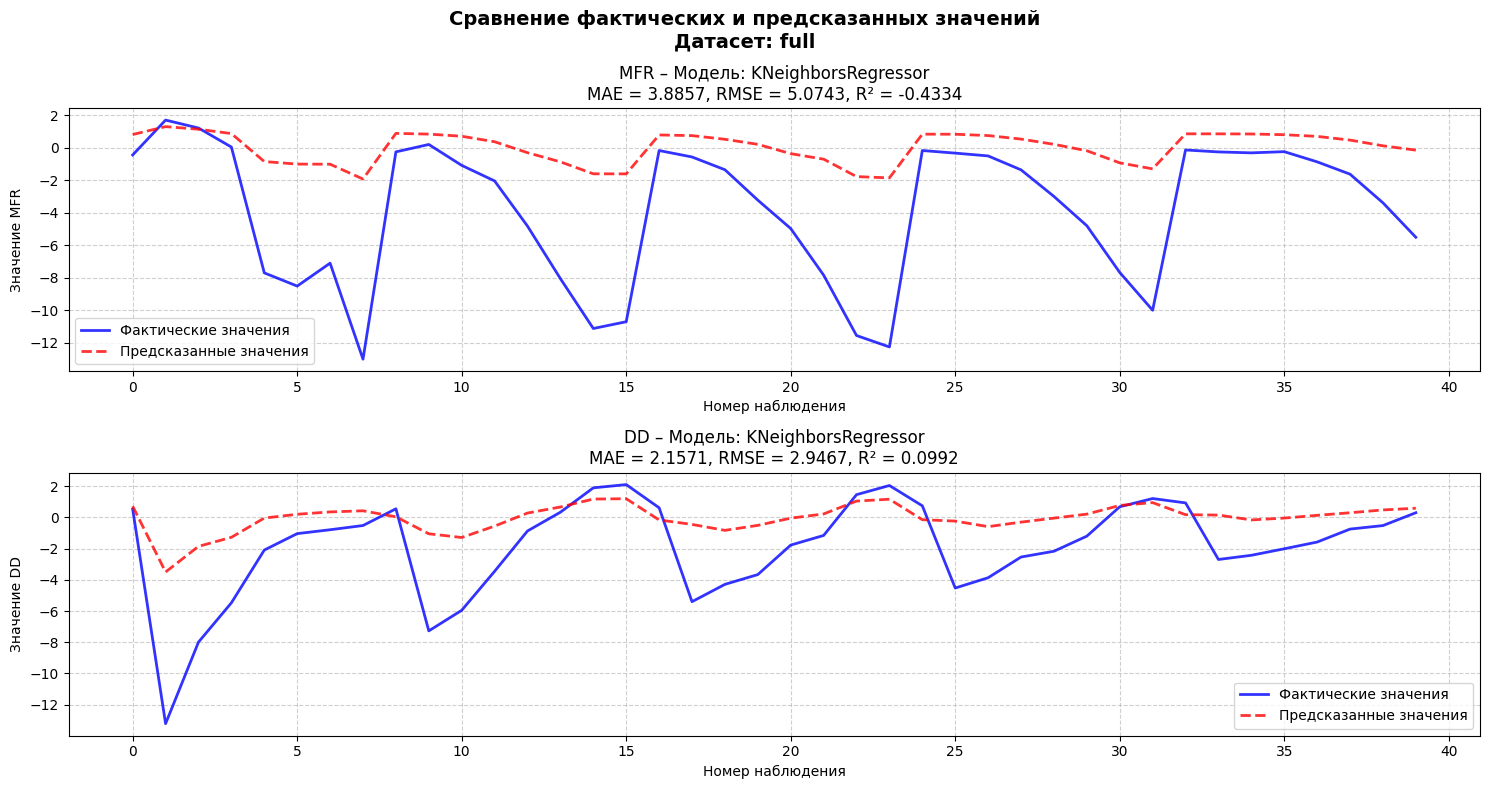

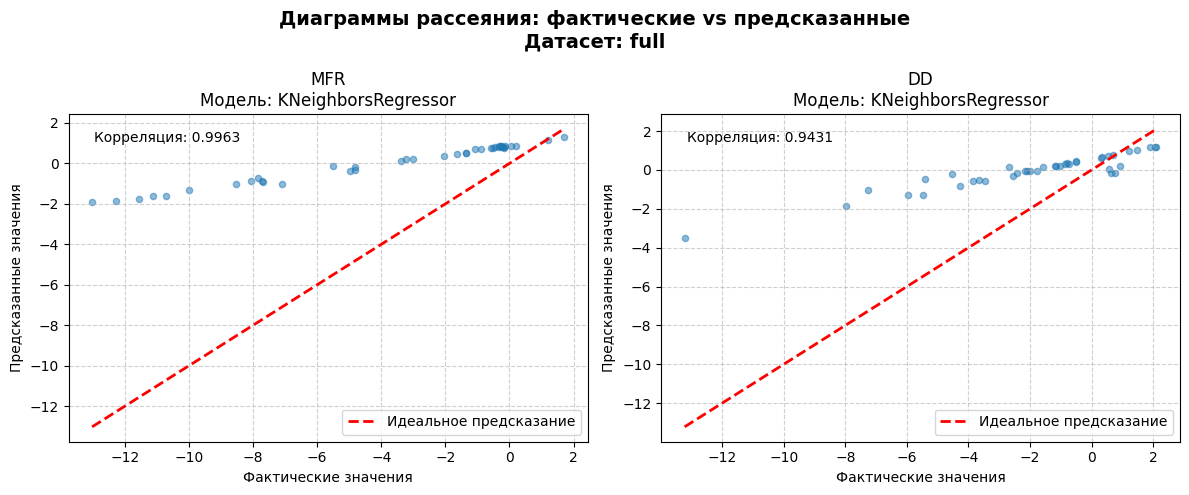

Предсказания для ds2 - MFR: форма (19,)
Предсказания для ds2 - DD: форма (19,)


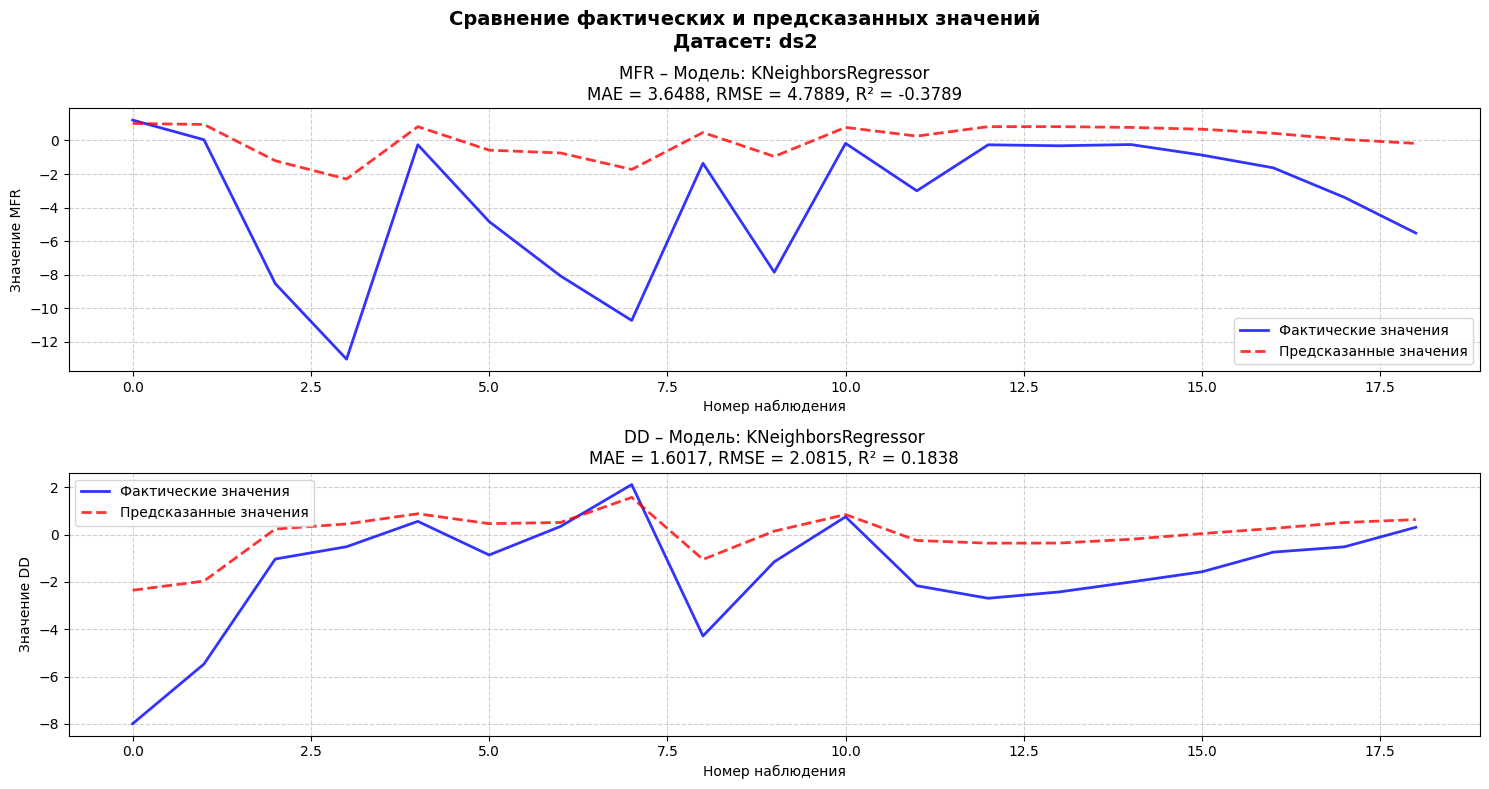

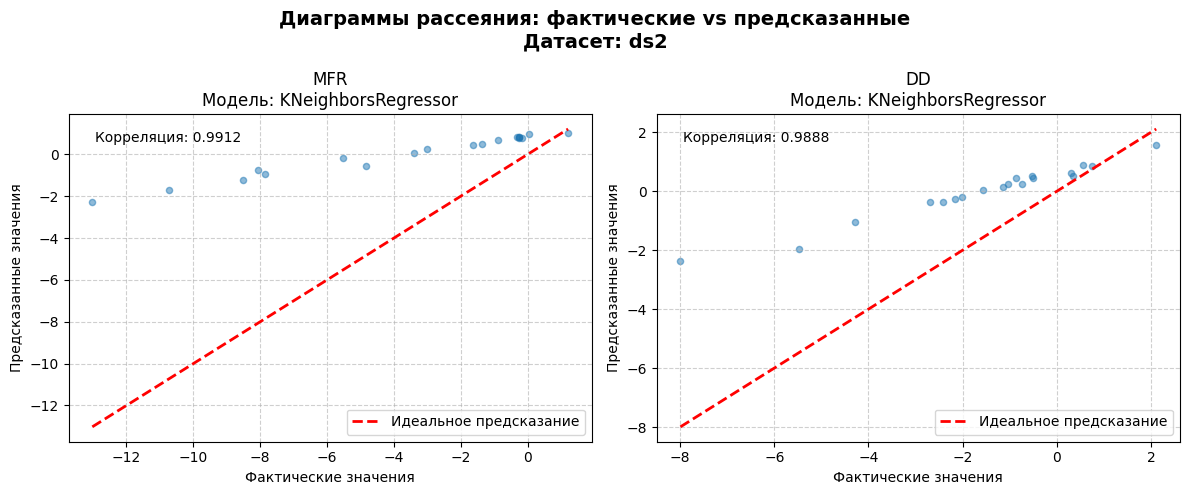

Предсказания для ds3 - MFR: форма (19,)
Предсказания для ds3 - DD: форма (19,)


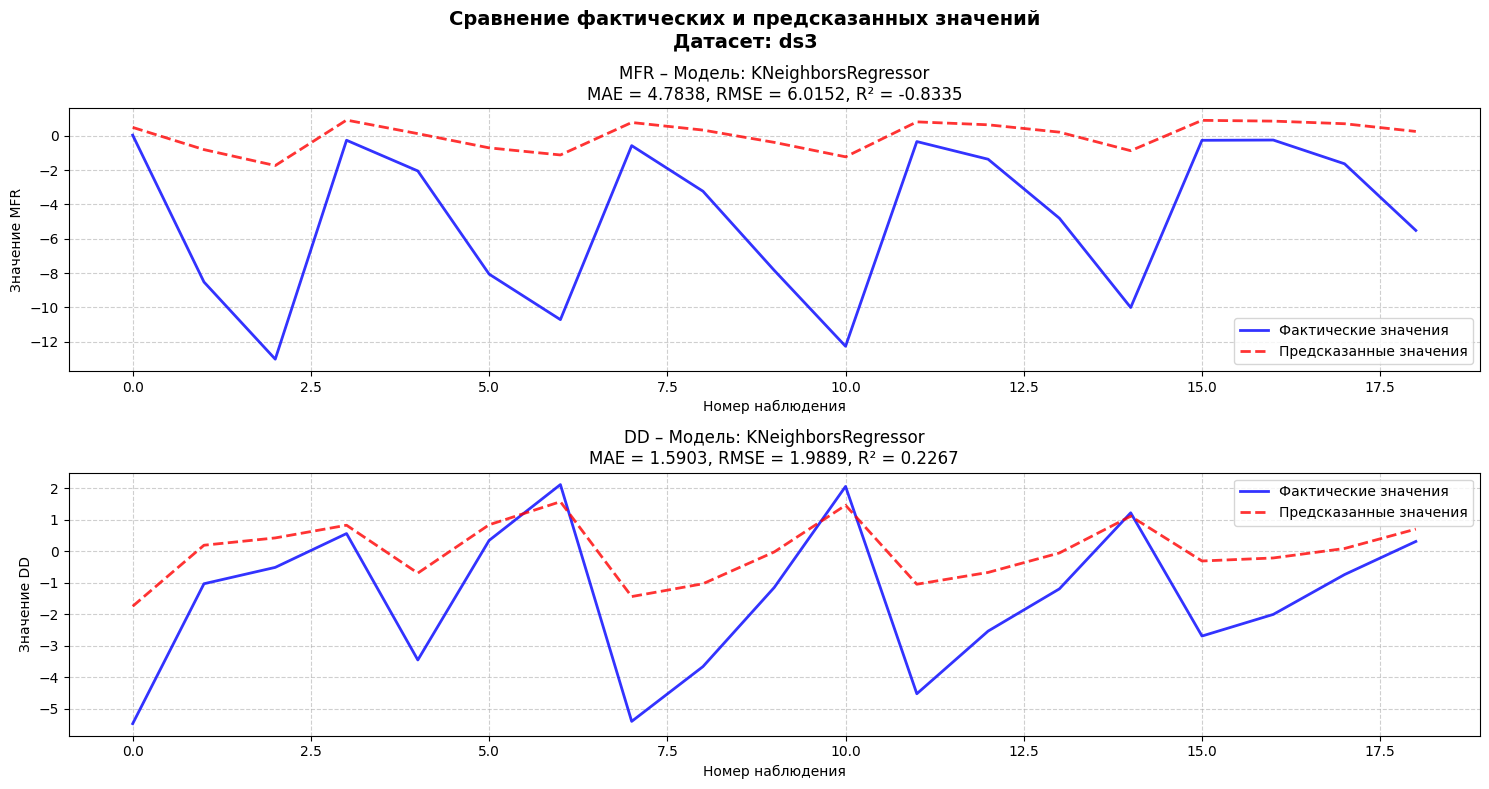

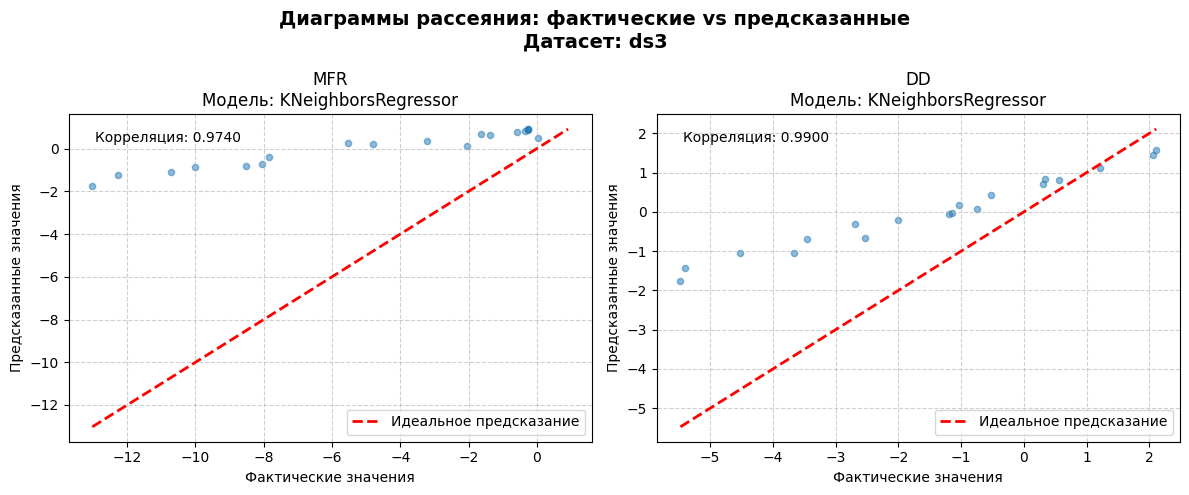

Предсказания для ds4 - MFR: форма (11,)
Предсказания для ds4 - DD: форма (11,)


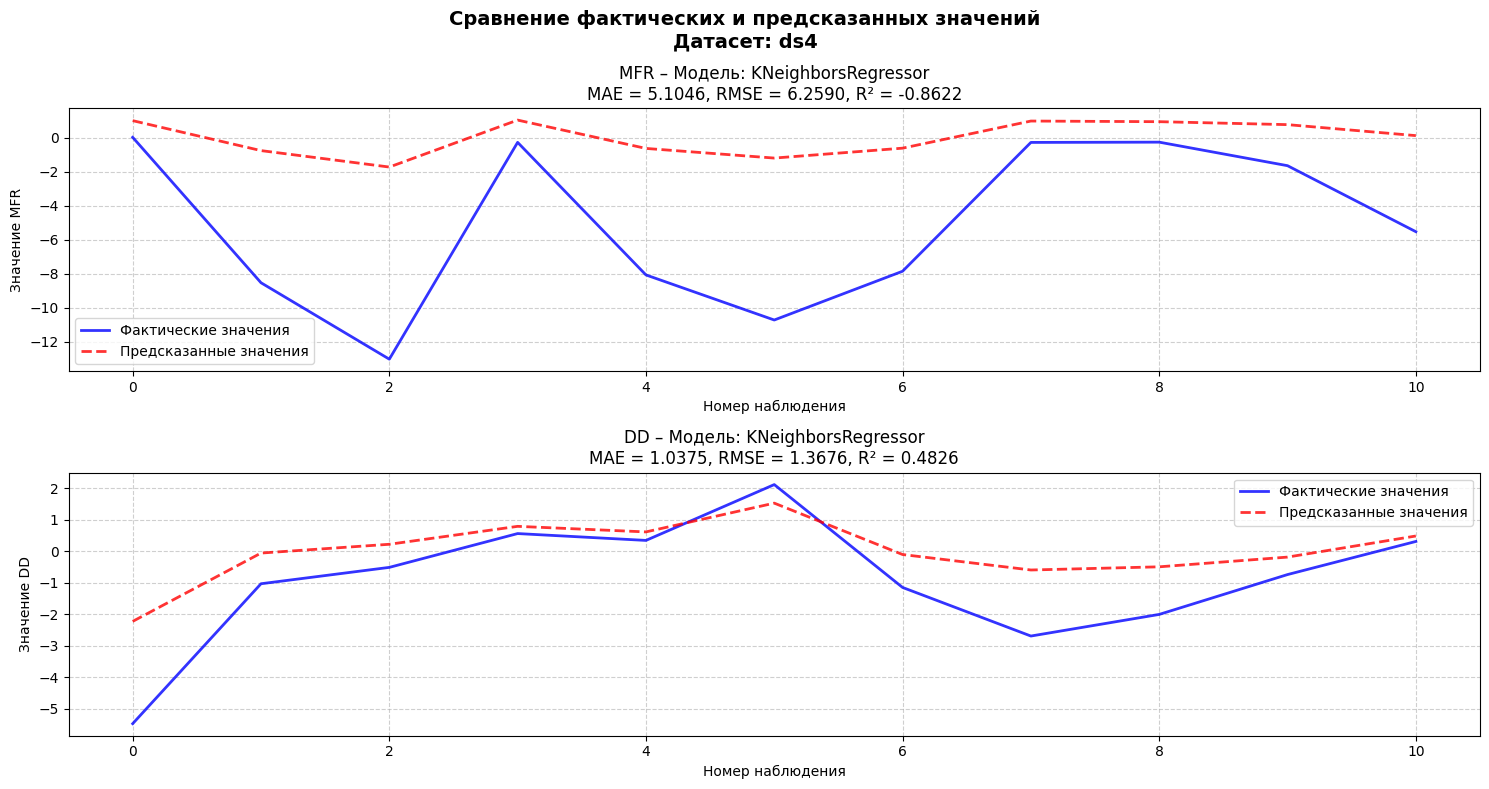

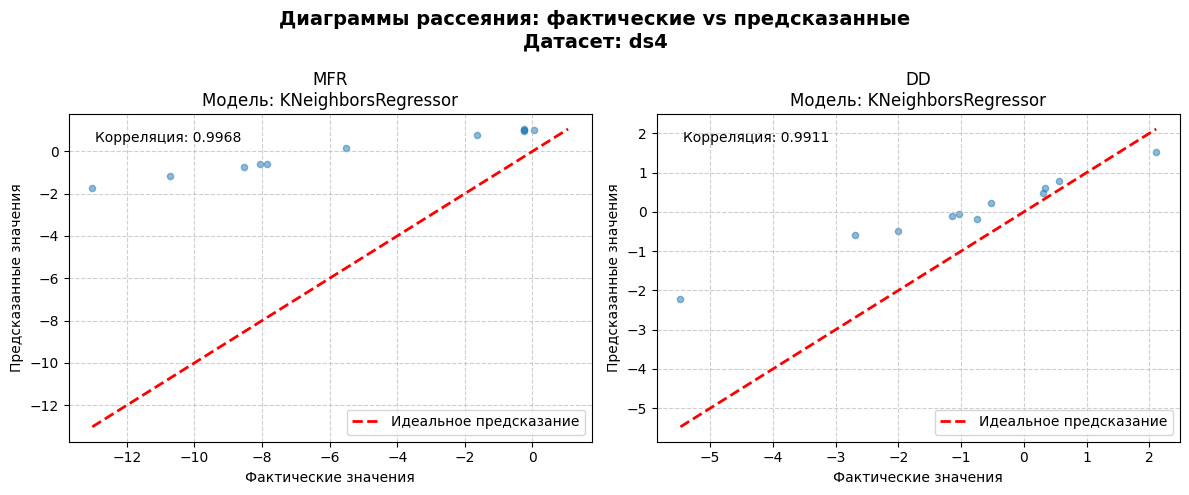

Предсказания для remaining - MFR: форма (35,)
Предсказания для remaining - DD: форма (35,)


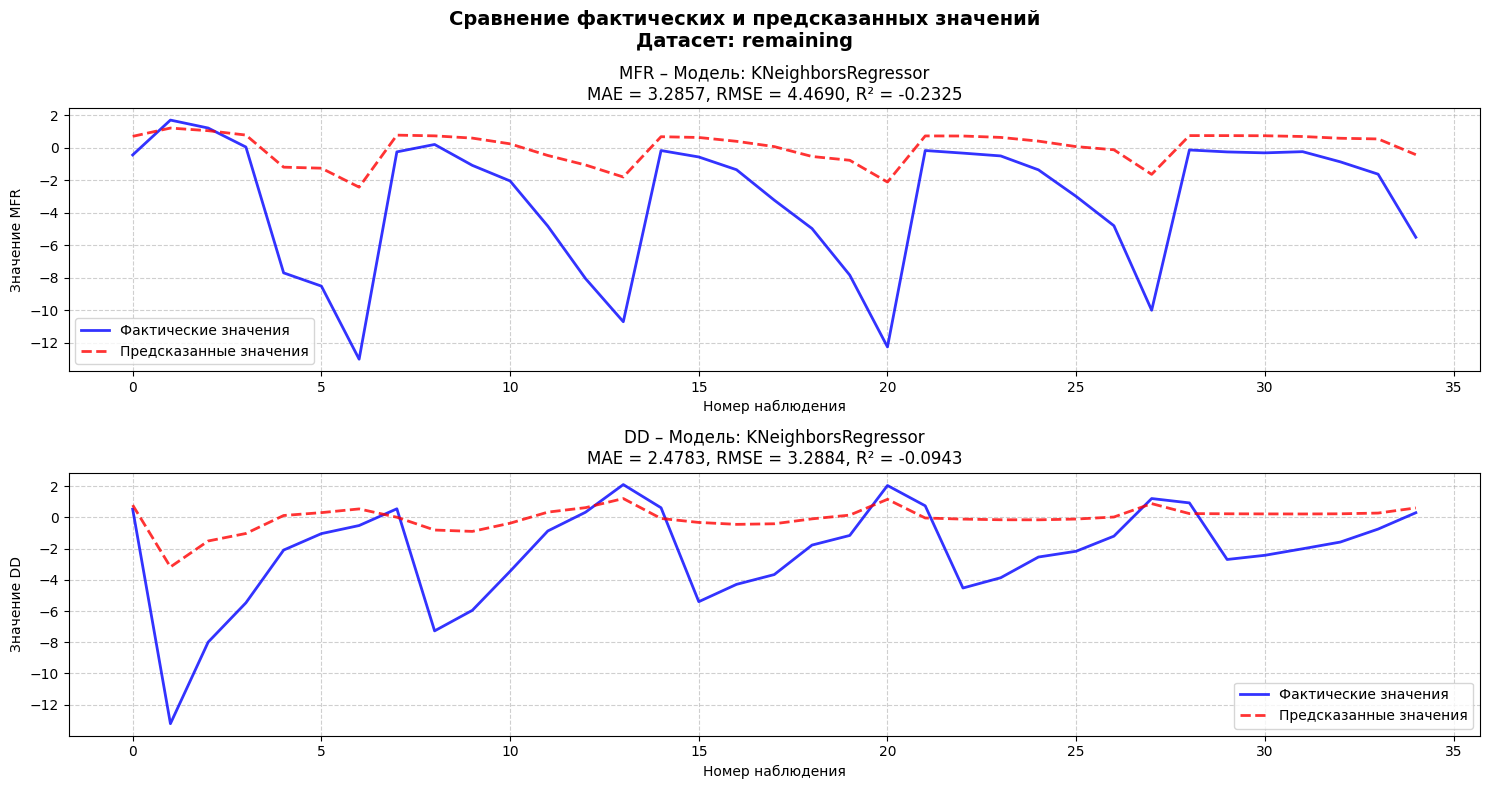

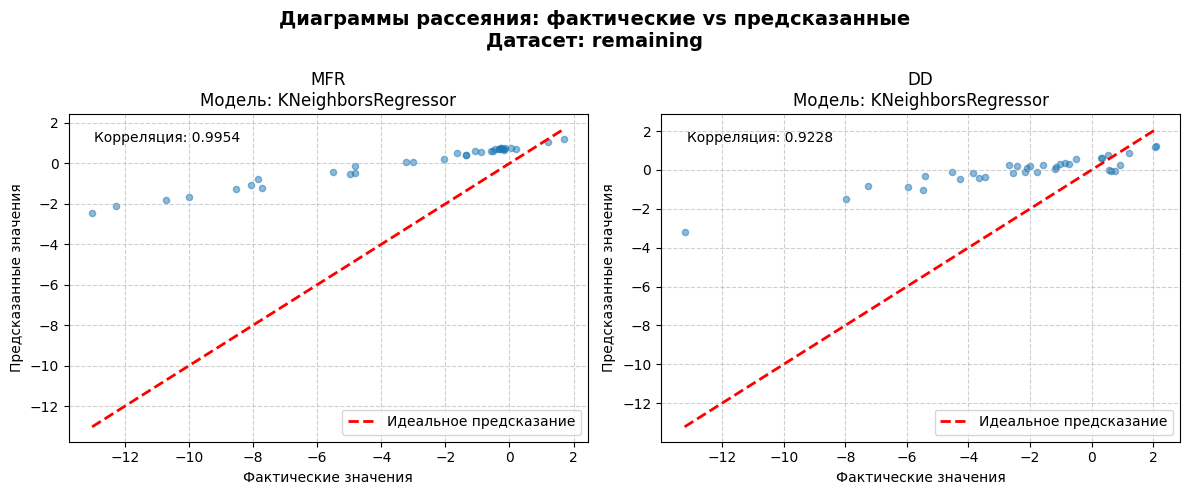

Ошибка при вычислении метрик для full-MFR: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Ошибка при вычислении метрик для full-DD: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Ошибка при вычислении метрик для ds2-MFR: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Ошибка при вычислении метрик для ds2-DD: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Ошибка при вычислении метрик для ds3-MFR: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Ошибка при вычислени

In [31]:
# ================== ПОДГОТОВКА ДАННЫХ ==================

# Словарь с исходными DataFrame для каждого датасета
original_dfs = {
    'full': df,
    'ds2': dataset2,
    'ds3': dataset3,
    'ds4': dataset4,
    'remaining': df_remaining
}

# Словарь с тестовыми данными (масштабированными) для каждого датасета
test_data = {
    'full': X_test_full_scaled,
    'ds2': X_test_full_ds2_scaled,
    'ds3': X_test_full_ds3_scaled,
    'ds4': X_test_full_ds4_scaled,
    'remaining': X_test_full_rem_scaled
}

# Словарь с индексами или названиями столбцов для целевых переменных
# Замените на актуальные индексы или названия столбцов в ваших DataFrame
target_columns = {
    'MFR': 12,   # индекс столбца с фактическими значениями MFR (0-based)
    'DD': 13     # индекс столбца с фактическими значениями DD
}

# ================== ПОСТРОЕНИЕ ГРАФИКОВ ==================

# Построение графиков для всех датасетов
plot_predictions_for_all_datasets(
    loaded_models=loaded_models,
    test_data=test_data,
    original_dfs=original_dfs,
    target_columns=target_columns,
    figsize=(15, 8)
)
# ================== ДОПОЛНИТЕЛЬНО: СВОДНЫЙ ГРАФИК СРАВНЕНИЯ МОДЕЛЕЙ ==================

# Построение сравнительного графика
comparison_results = plot_comparison_across_datasets(
    loaded_models=loaded_models,
    test_data=test_data,
    original_dfs=original_dfs,
    target_columns=target_columns
)

# Вывод таблицы с результатами
if comparison_results is not None:
    print("\nСводная таблица результатов:")
    print(comparison_results.to_string(index=False))